В файле **WIPO-GII_2022.xlsx** содержаться данные по странам о показателях, используемых для расчета Global Innovation Index за 2022 год.

[Подробнее](https://prosperitydata360.worldbank.org/en/indicator/WIPO+GII+235)

### В файле следующие переменные:
- Country
- Business environment
- Business sophistication index
- Citable documents H-index
- Creative goods and services
- Creative goods exports, % total trade
- Creative outputs index
- Cultural and creative services exports, % total trade
- Domestic market scale, bn PPP
- Ecological sustainability
- Expenditure on education, % GDP
- Firms offering formal training, %
- General infrastructure
- Government effectiveness
- Government's online service
- Graduates in science and engineering, %
- Gross expenditure on R&D, % GDP
- High-tech exports, % total trade
- High-tech imports, % total trade
- High-tech manufacturing, %
- Human capital and research index
- Information and Communications Technology access
- Information and Communications Technology services exports, % total trade
- Information and Communications Technology services imports, % total trade
- Information and Communications Technology use
- Infrastructure index
- Intangible assets
- Joint venture/strategic alliance deals/bn PPP GDP
- Knowledge absorption
- Knowledge and technology outputs index
- Knowledge workers
- Knowledge-intensive employment, %
- Logistics performance
- Market sophistication index
- Mobile app creation/bn PPP GDP
- Online creativity
- PISA scales in reading, maths and science
- Political and operational stability
- Political environment
- Pupil-teacher ratio, secondary
- QS university ranking average score of top 3 universities
- Research and development (R&D)
- Scientific and technical articles/bn PPP GDP
- Software spending, % GDP
- Tertiary education
- Tertiary enrolment, % gross
- University-industry R&D collaboration
- Region
- Region2
- Euro area
- European Union
- OECD members
- Least developed countries
- Income
- High income

Выполните, пожалуйста, задания.

##Задание 1

1. Выберите не менее 10 интересующих Вас метрических переменных для последующего проведения кластерного анализа данных. Если между ними наблюдаются корреляции, то рассчитайте на их основе компоненты, используя метод главных компонент. Возможно, что имеет смысл выделить компоненты не на основе всех рассматриваемых переменных, а только на части изначально отобранных переменных. Интерпретируйте результаты расчёта показателя KMO. Дайте названия полученным компонентам, по которым можно было бы понять, что именно они оценивают. Подробно опишите каждый компонент и обоснуйте выбор названия. Укажите процент вариации исходных переменных, отраженный в выделенных компонентах. Сохраните компоненты в виде переменных в датасете.

_Если не удается выделить компоненты на имеющихся данных, то приведите расчеты и аргументы, подтверждающие это._

In [127]:
import pandas as pd

In [128]:
url = '/content/WIPO-GII_2022.xlsx'

In [129]:
df = pd.read_excel(url)
df

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,"Tertiary enrolment, % gross_2022",University-industry R&D collaboration_2022,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income
0,Cote d'Ivoire,48.3,21.8,5.1,1.2,0.3,6.0,2.1,3.4,23.7,...,4.0,38.5,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,0,middle income,0
1,Czechia,42.1,46.2,30.4,40.6,100.0,29.9,15.3,10.3,47.3,...,42.6,59.1,Europe & Central Asia,Europe,0,1,1,0,high income,1
2,"Egypt, Arab Rep.",45.0,20.4,18.0,9.1,16.9,14.1,0.0,30.9,25.4,...,24.1,47.0,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0
3,"Hong Kong SAR, China",69.7,46.7,38.4,47.4,100.0,53.2,3.0,10.8,56.3,...,55.6,62.9,East Asia & Pacific,Asia-Pacific,0,0,0,0,high income,1
4,"Iran, Islamic Rep.",13.3,18.6,22.1,4.0,1.2,31.8,4.2,26.6,14.7,...,37.5,27.7,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Paraguay,28.8,23.1,3.2,0.6,1.1,18.1,0.1,2.1,25.2,...,0.0,26.8,Latin America & Caribbean,Americas,0,0,0,0,middle income,0
135,Peru,50.4,32.1,14.4,12.6,2.7,19.5,2.6,10.0,31.6,...,46.1,32.7,Latin America & Caribbean,Americas,0,0,0,0,middle income,0
136,Trinidad and Tobago,47.6,20.5,4.0,1.7,1.7,4.5,0.0,0.6,17.1,...,0.0,33.6,Latin America & Caribbean,Americas,0,0,0,0,high income,1
137,United States,75.3,64.5,100.0,44.8,33.8,48.4,38.8,100.0,25.4,...,58.0,79.6,North America,Americas,0,0,1,0,high income,1


In [130]:
pip install yellowbrick

In [131]:
%matplotlib inline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings("ignore")

In [132]:
pip install factor_analyzer

In [133]:
from factor_analyzer import FactorAnalyzer, Rotator
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

In [134]:
df.info() #расчет количества ненулевых значений по каждой переменной

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 55 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Country                                                                         139 non-null    object 
 1   Business environment_2022                                                       132 non-null    float64
 2   Business sophistication index_2022                                              132 non-null    float64
 3   Citable documents H-index_2022                                                  132 non-null    float64
 4   Creative goods and services_2022                                                132 non-null    float64
 5   Creative goods exports, % total trade_2022                                      132 non-null    float64
 6   Creative outputs i

In [135]:
corr_mtrx = df.corr(numeric_only=True).abs()

corrmax = (corr_mtrx.where(np.triu(np.ones(corr_mtrx.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
corrmax.head(25)

#код для поиска пар переменных с наиболее высоким значением парной корреляции
#здесь исключается диагональ, где парное значение корреляции равно 1

,,0
Government effectiveness_2022,Political environment_2022,0.976950
Political and operational stability_2022,Political environment_2022,0.954470
Business sophistication index_2022,Knowledge workers_2022,0.934362
Creative outputs index_2022,Intangible assets_2022,0.924249
QS university ranking average score of top 3 universities_2022,Research and development (R&D)_2022,0.923189
Citable documents H-index_2022,Research and development (R&D)_2022,0.921029
Information and Communications Technology use_2022,Infrastructure index_2022,0.914534
Citable documents H-index_2022,QS university ranking average score of top 3 universities_2022,0.910849
Information and Communications Technology access_2022,Information and Communications Technology use_2022,0.905812
Business sophistication index_2022,Knowledge and technology outputs index_2022,0.903413


[Источник кода из строки выше](https://translated.turbopages.org/proxy_u/en-ru.ru.85379b8d-67b99710-75331c9f-74722d776562/https/stackoverflow.com/questions/17778394/list-highest-correlation-pairs-from-a-large-correlation-matrix-in-pandas)

Были выведены 25 пар переменных с наиболее высокими значениями парной корреляции.
Предварительно смотрим, какие переменные чаще всего встречаются в этом списке (имеют больше всего корреляций с другими), есть ли какое-то логическое обоснование этой связи, создаются ли логические группы переменных, между которыми наблюдается высокая корреляция.
Можно отметить высокую корреляцию между переменными Government effectiveness_2022, Political environment_2022 и Political and operational stability_2022, которые характеризуют качество развития политических институтов стран.
Анализируя пары переменных, можно выделить группу переменных с высокой парной корреляцией, характеризующую страны по уровню развития науки и технологий. Таким образом, будем выбирать переменные, которые имеют высокую корреляцию и логическую взаимосвязь с определенным набором других переменных в датасете, чтобы можно было создать группы (факторы/компоненты).

Предварительно выделим следующие переменные, чтобы взять их для факторного анализа...

Далее рассмотрим тепловую диаграмму, где отображены корреляции и сила взаимосвязи между всеми переменными датасета.

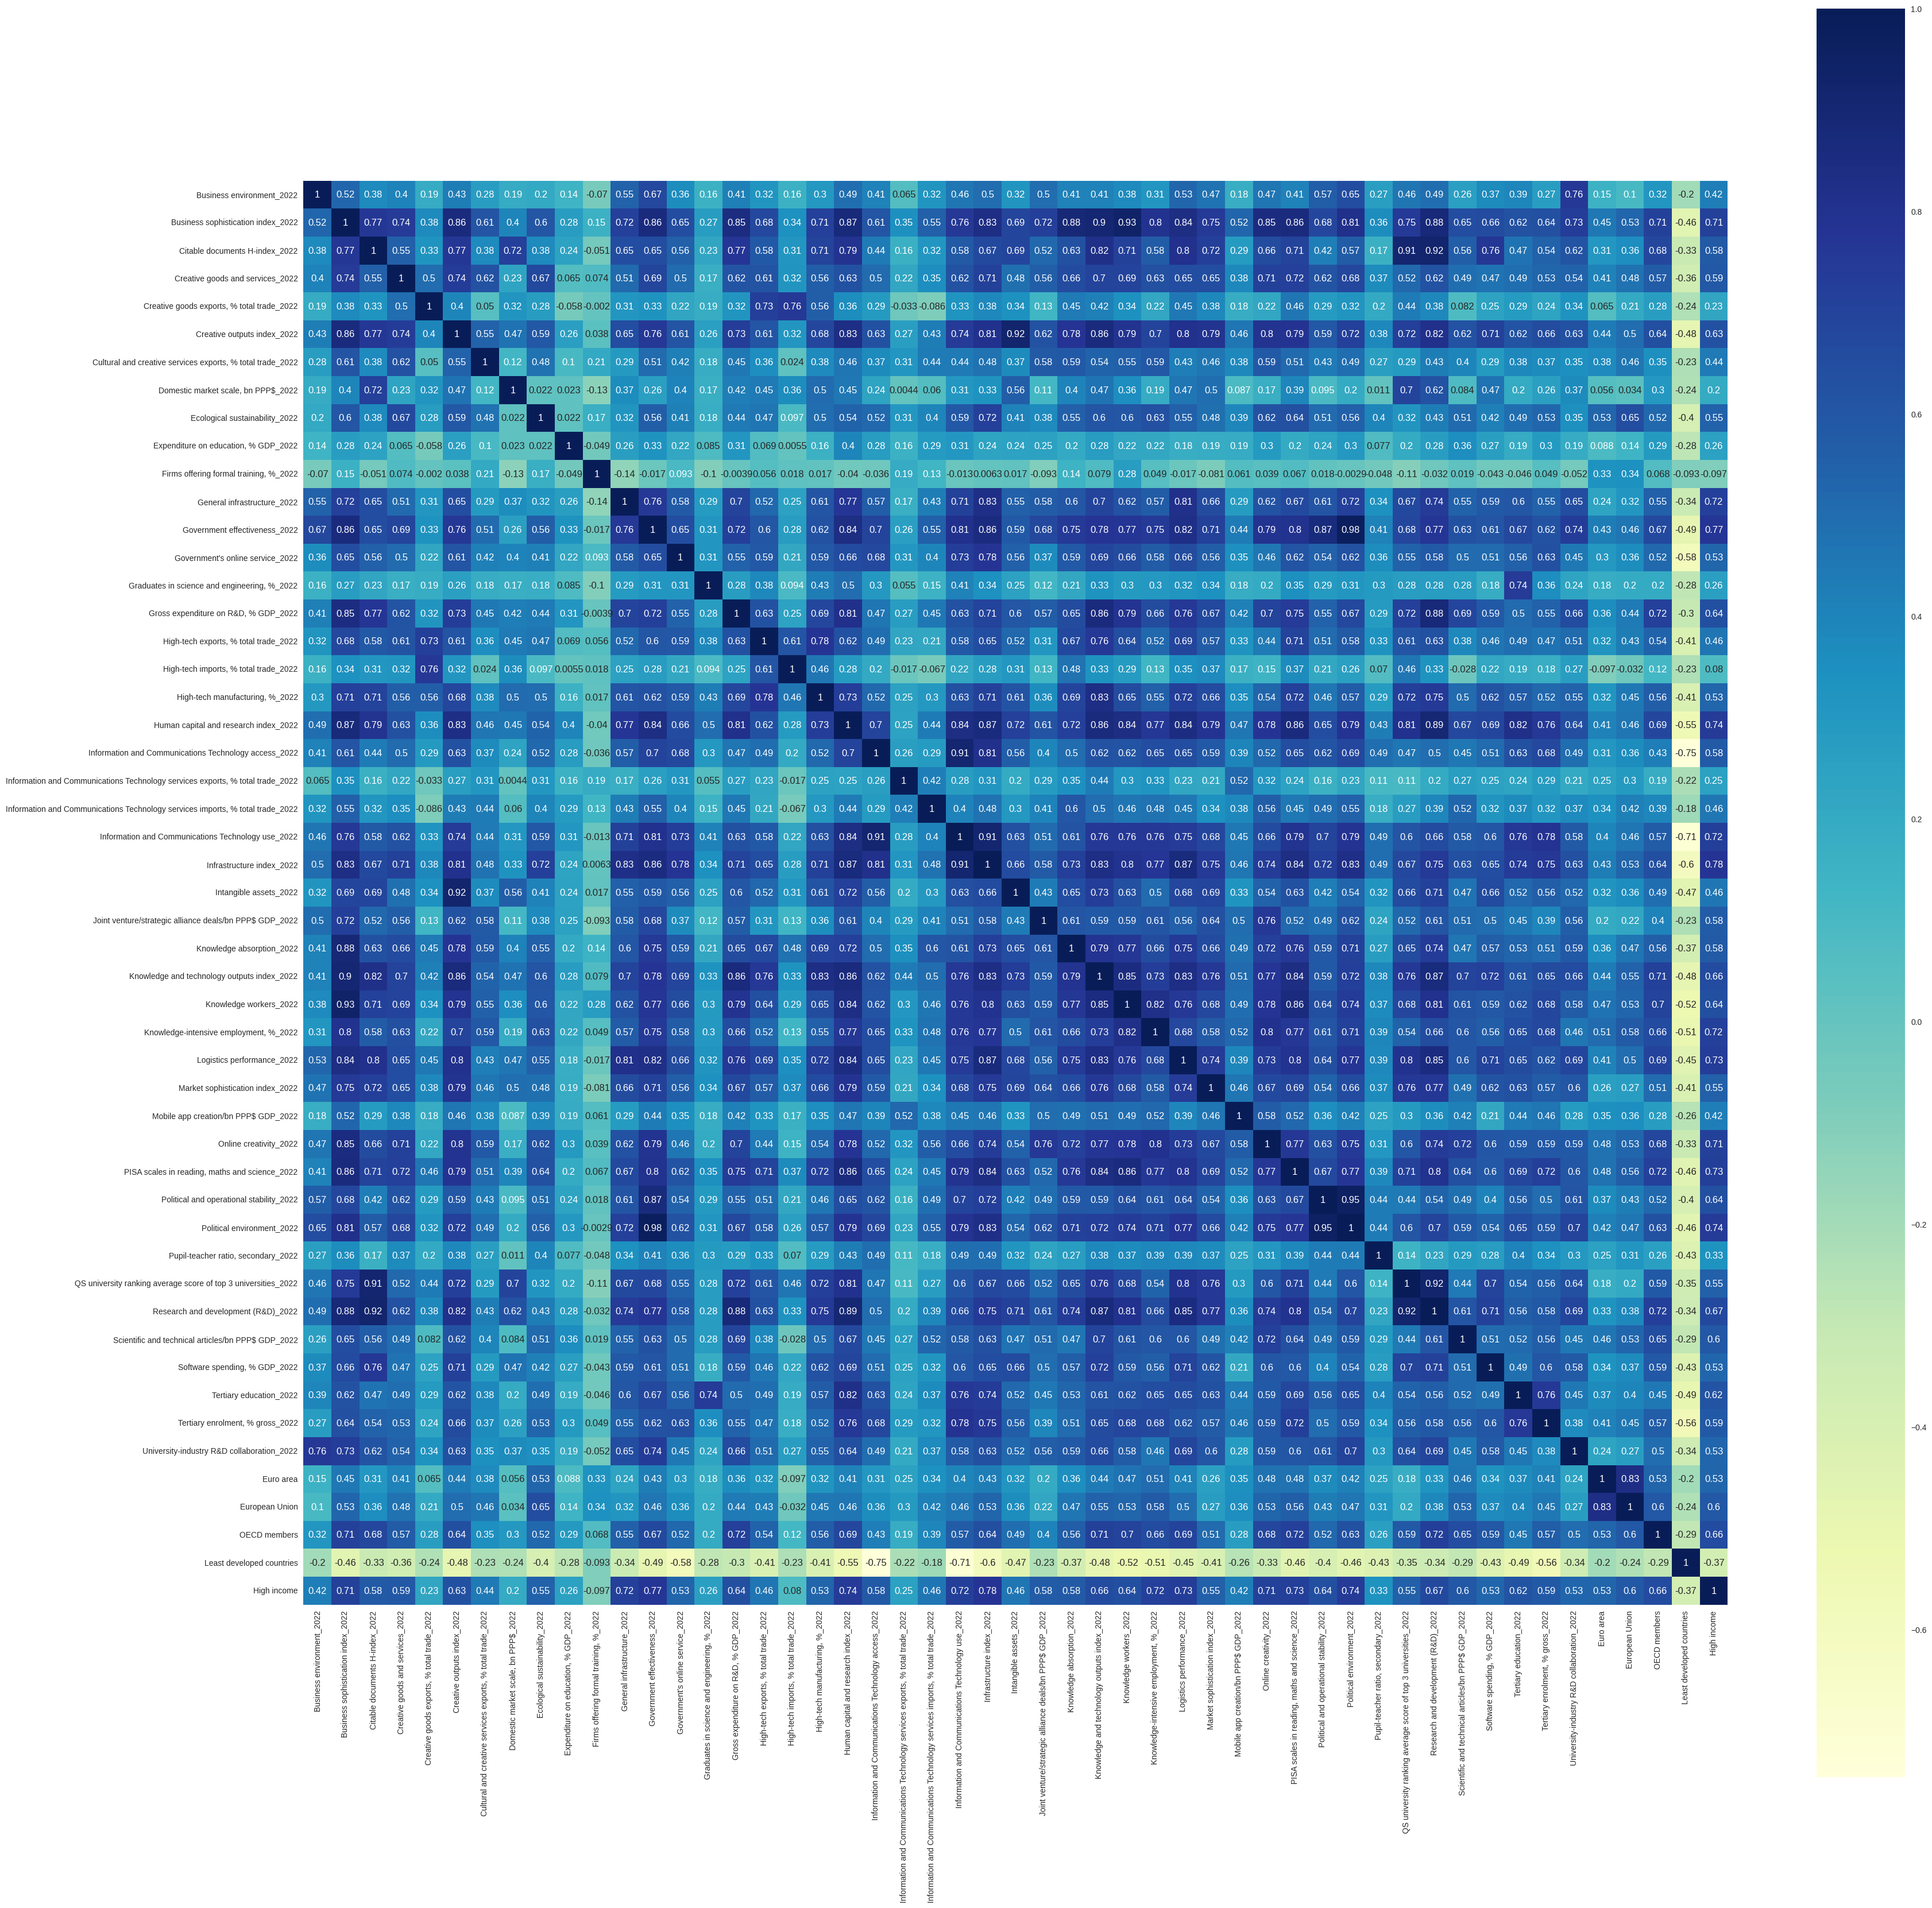

In [136]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(40, 40))
sns.heatmap(cor, square = True, cmap='YlGnBu', annot=True)
plt.show() #также построим тепловую диаграмму с отображением парных корреляций для выбранных переменнных
#из нее более заметно, между какими переменными более значительная высокая корреляция

Были выбраны 14 переменных: Government effectiveness_2022, Political and operational stability_2022, Political environment_2022, Human capital and research index_2022, Research and development (R&D)_2022, Knowledge workers_2022, QS university ranking average score of top 3 universities_2022, Knowledge and technology outputs index_2022, Information and Communications Technology use_2022, Infrastructure index_2022, Citable documents H-index_2022, Gross expenditure on R&D, % GDP_2022, Business sophistication index_2022, Information and Communications Technology access_2022.

In [137]:
dff = df[['Government effectiveness_2022', 'Political and operational stability_2022', 'Political environment_2022', 'Human capital and research index_2022', 'Research and development (R&D)_2022',
          'Knowledge workers_2022', 'QS university ranking average score of top 3 universities_2022', 'Knowledge and technology outputs index_2022',
          'Information and Communications Technology use_2022', 'Infrastructure index_2022', 'Citable documents H-index_2022',
          'Gross expenditure on R&D, % GDP_2022', 'Business sophistication index_2022', 'Information and Communications Technology access_2022']]
#формируем датасет, который будет содержать только выбранные переменные, которые будут использоваться в анализе

In [138]:
dff

,Government effectiveness_2022,Political and operational stability_2022,Political environment_2022,Human capital and research index_2022,Research and development (R&D)_2022,Knowledge workers_2022,QS university ranking average score of top 3 universities_2022,Knowledge and technology outputs index_2022,Information and Communications Technology use_2022,Infrastructure index_2022,Citable documents H-index_2022,"Gross expenditure on R&D, % GDP_2022",Business sophistication index_2022,Information and Communications Technology access_2022
0,39.4,67.3,53.3,11.8,0.2,17.2,0.0,11.0,40.5,32.8,5.1,1.1,21.8,65.2
1,70.3,81.8,76.1,43.3,24.5,45.6,31.5,44.7,73.8,58.3,30.4,36.5,46.2,89.7
2,38.0,60.0,49.0,20.3,11.1,13.8,19.8,18.2,51.1,35.5,18.0,17.5,20.4,81.1
3,85.5,81.8,83.7,57.4,58.4,46.1,82.9,23.1,83.0,63.7,38.4,18.0,46.7,98.2
4,28.4,45.5,36.9,35.0,14.4,19.2,25.8,26.7,68.2,41.1,22.1,16.1,18.6,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,39.7,63.6,51.6,19.2,0.7,22.5,0.0,11.0,49.8,41.1,3.2,2.3,23.1,73.0
135,44.6,61.8,53.2,36.8,7.8,46.0,18.1,13.7,50.5,40.5,14.4,3.0,32.1,70.4
136,53.6,70.9,62.2,23.1,1.1,26.0,0.0,14.5,59.3,36.5,4.0,0.9,20.5,89.1
137,78.1,78.2,78.2,59.9,86.1,75.0,98.9,60.8,84.0,58.7,100.0,63.4,64.5,89.5


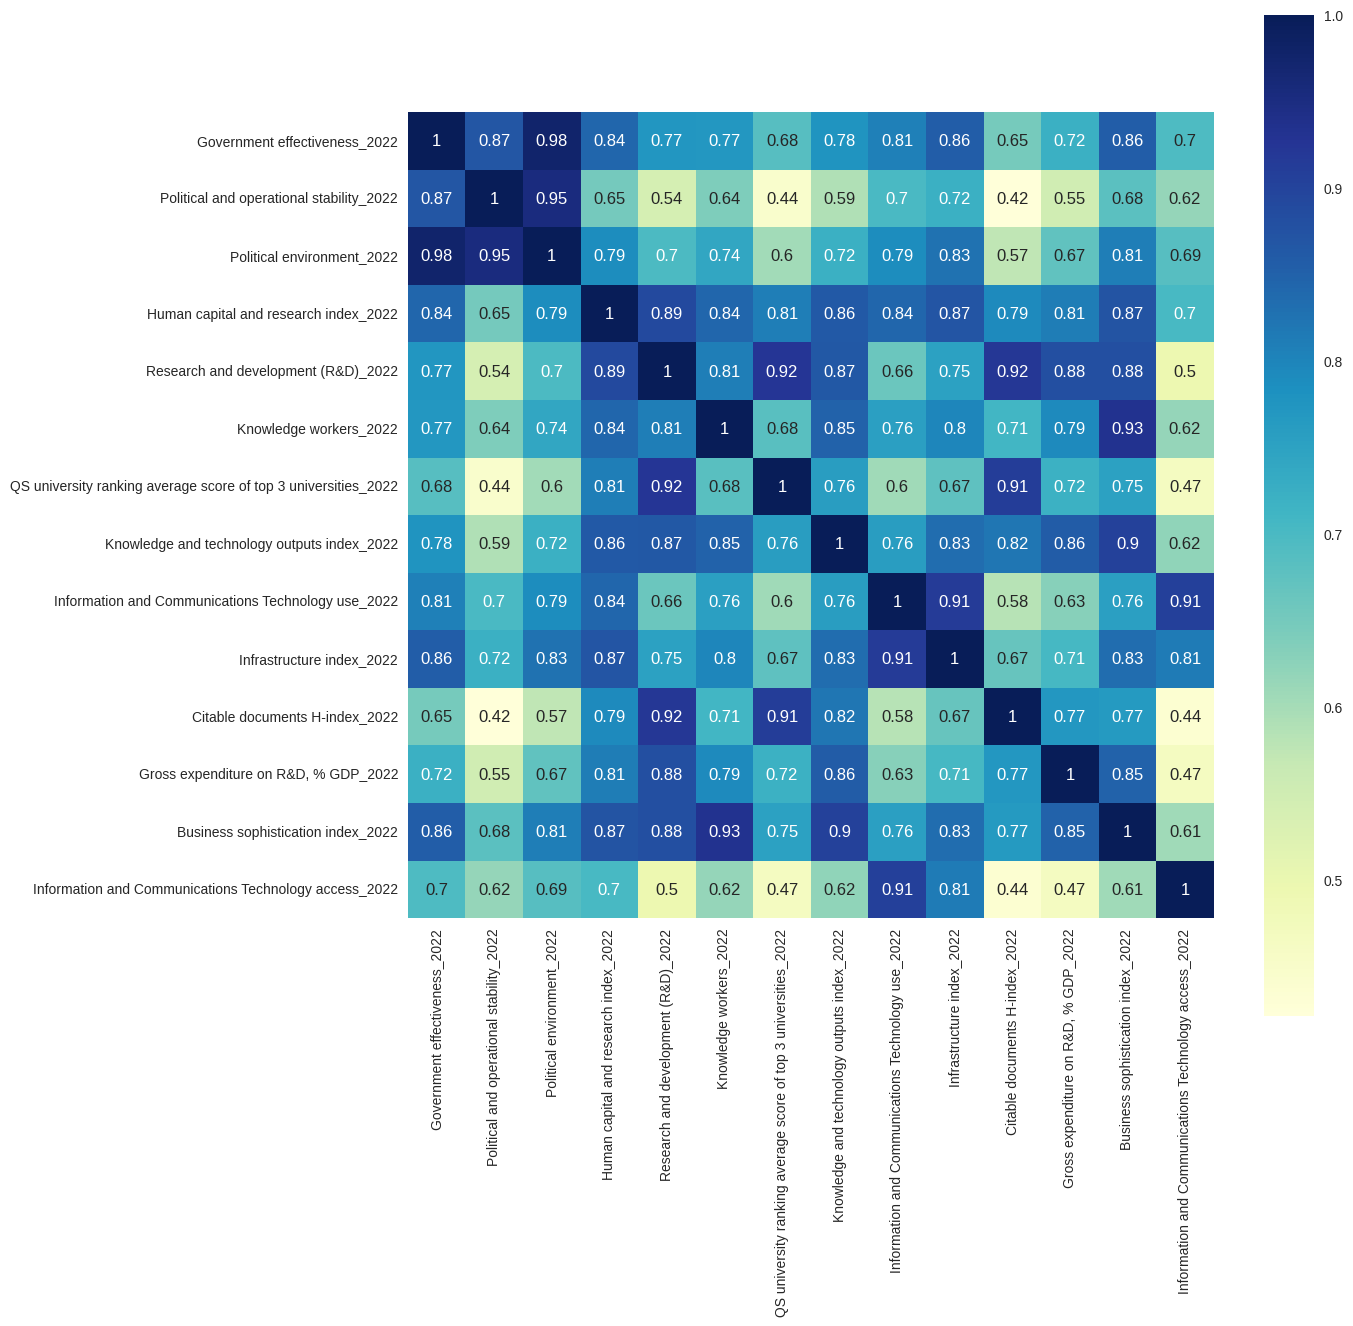

In [139]:
cor = dff.corr(numeric_only=True)
plt.figure(figsize=(13, 13))
sns.heatmap(cor, square = True, cmap='YlGnBu', annot=True)
plt.show() #построим тепловую диаграмму с отображением парных корреляций для выбранных переменнных

####Оценка применимости факторного анализа данных

Проведем тест сферичности Бартлетта для проверки на наличие коррелированных переменных.

Гипотезы:

H0: корреляция между переменными отсутствует (корреляционная матрица является единичной матрицей)

H1: есть корреляция между переменными

In [140]:
calculate_bartlett_sphericity(dff.dropna()) #второе значение - p-value

(4401.699407483709, 0.0)

Так как p-value < 0.05, H0 отклоняется, что означает, что между переменными есть достаточное количество статистически значимых коррелляций для проведения факторного анализа.

Для дополнительной проверки целесообразности проведения факторного анализа, используем Критерий адекватности выборки Кайзера-Мейера-Олкина (КМО). Он позволит выявить, насколько корреляции между переменными можно объяснить некоторым количеством факторов.

In [141]:
_, kmo_model = calculate_kmo(dff.dropna())
kmo_model #KMO

0.8881185503633663

Значение критерия высокое, приближено к 1, поэтому в данном случае может быть применена факторная модель.

###Z-стандартизация

Так как значения имеют разные шкалы (единицы измерения), сначала проведем z-стандартизацию переменных, чтобы можно было их анализировать в общей шкале и далее иметь возможность провести факторный анализ.

In [142]:
dff2 = dff.apply(lambda x: (x-x.mean()) / x.std() if x.std() != 0 else x, axis=0)

In [143]:
dff2

,Government effectiveness_2022,Political and operational stability_2022,Political environment_2022,Human capital and research index_2022,Research and development (R&D)_2022,Knowledge workers_2022,QS university ranking average score of top 3 universities_2022,Knowledge and technology outputs index_2022,Information and Communications Technology use_2022,Infrastructure index_2022,Citable documents H-index_2022,"Gross expenditure on R&D, % GDP_2022",Business sophistication index_2022,Information and Communications Technology access_2022
0,-0.734049,-0.082365,-0.479970,-1.346105,-0.765131,-0.872646,-0.769447,-0.867774,-0.842261,-0.823379,-0.686218,-0.749636,-0.707299,-0.803900
1,0.827217,0.937999,0.905525,0.689872,0.215347,0.569696,0.409345,1.303687,0.690822,1.138046,0.446154,1.066466,1.008373,0.598902
2,-0.804786,-0.596065,-0.741269,-0.796714,-0.325328,-1.045321,-0.028492,-0.403842,-0.354252,-0.615698,-0.108843,0.091722,-0.805740,0.106490
3,1.595218,0.937999,1.367356,1.601214,1.583175,0.595089,2.332835,-0.088110,1.114376,1.553406,0.804216,0.117373,1.043530,1.085589
4,-1.289839,-1.616429,-1.476553,0.153408,-0.192177,-0.771073,0.196040,0.143856,0.433006,-0.184954,0.074664,0.019899,-0.932306,0.501565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.718891,-0.342733,-0.583274,-0.867812,-0.744957,-0.603477,-0.769447,-0.867774,-0.414103,-0.184954,-0.771258,-0.688073,-0.615891,-0.357294
135,-0.471312,-0.469399,-0.486046,0.269750,-0.458480,0.590011,-0.092109,-0.693799,-0.381876,-0.231105,-0.269971,-0.652161,0.016939,-0.506163
136,-0.016574,0.170967,0.060859,-0.615739,-0.728817,-0.425723,-0.769447,-0.642251,0.023263,-0.538780,-0.735452,-0.759896,-0.798708,0.564548
137,1.221323,0.684667,1.033136,1.762800,2.700840,2.062825,2.931586,2.341090,1.160415,1.168813,3.561295,2.446498,2.295127,0.587451


In [144]:
dff2.shape #расчет размерности получившегося датасета, сразу видно кол-во взятых переменных

(139, 14)

In [145]:
model1 = FactorAnalyzer(n_factors=14, rotation='varimax', method='principal')
#строим модель для 14 компонент, что соответствует общему числу переменных
model1.fit(dff2)

FactorAnalyzer(method='principal', n_factors=14, rotation='varimax',
               rotation_kwargs={})

###Расчет собственных значений и определение числа компонент

In [146]:
ev, v = model1.get_eigenvalues()
ev #расчет 14 собственных значений

array([1.07006993e+01, 1.41708559e+00, 6.58921412e-01, 4.19150794e-01,
       2.00031252e-01, 1.43861179e-01, 1.23676859e-01, 9.39343002e-02,
       7.88696242e-02, 6.07220570e-02, 4.99723323e-02, 3.43842634e-02,
       1.85742990e-02, 1.16699118e-04])

In [147]:
ev[ev > 1]

array([10.70069934,  1.41708559])

Из получившихся 14 собственных значений только 2 выше 1. Если для определения числа компонент берем за критерий факт того, что собственные значения должны превышать 1, то следует оставить 2 компоненты.



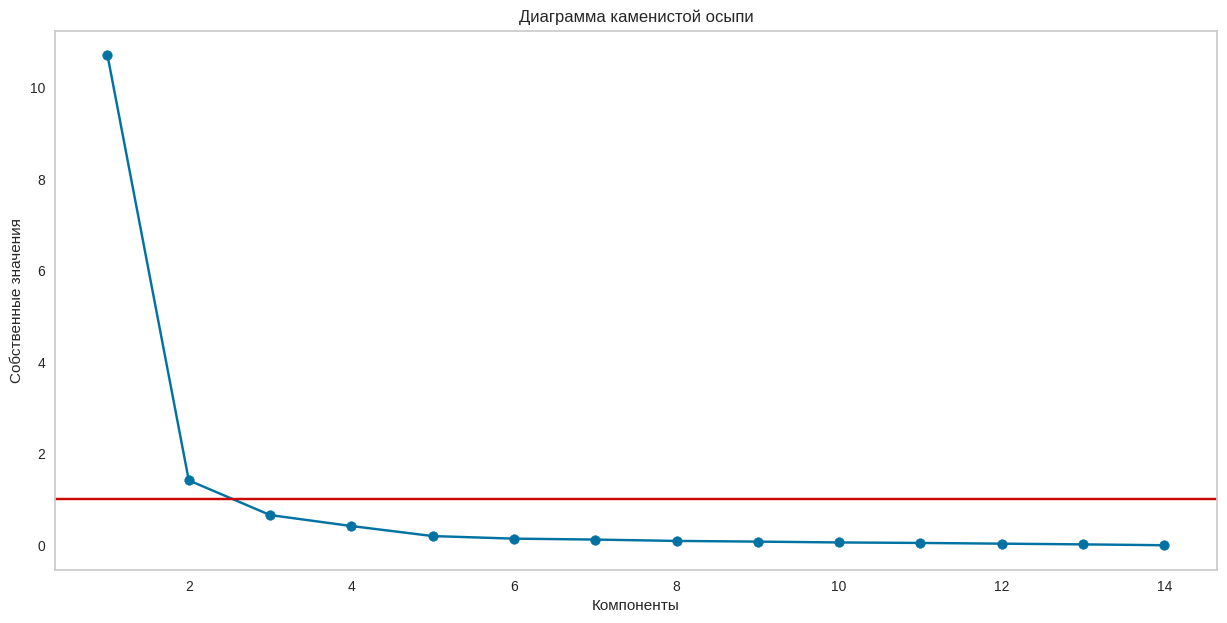

In [148]:
plt.figure(figsize=(15, 7))
plt.scatter(range(1, dff2.shape[1]+1), ev)
plt.plot(range(1, dff2.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='-')
plt.title('Диаграмма каменистой осыпи')
plt.xlabel('Компоненты')
plt.ylabel('Собственные значения')
plt.grid()
plt.show()

По диаграмме каменистой осыпи также можно определить, что только 2 собственных значения больше 1.
Но если принять во внимание другой критерий оценки количества компонент, то можно отметить по графику каменистой осыпи, что собственные значения меняются вплоть до 3 компонент. Собственные значения для большего количества компонент перестают менятся (почти равны между собой). По данному критерию можно оставить 3 компоненты.

###Построение модели

Попробуем сначала выделить 2 компоненты, а позже рассмотреть случай с 3 группами переменными. Сравним результат, чтобы определить, в какой ситуации удается более рационально интерпритировать смысл получившихся компонент.

####Случай с 2 компонентами

In [149]:
model0 = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal') #строим модель с 3 компонентами
model0.fit(dff2)

FactorAnalyzer(method='principal', n_factors=2, rotation='varimax',
               rotation_kwargs={})

In [150]:
model0.loadings_

array([[0.51822147, 0.79480243],
       [0.23272316, 0.86454432],
       [0.4146687 , 0.85024273],
       [0.73000032, 0.60734969],
       [0.9209071 , 0.34643705],
       [0.69344617, 0.5728339 ],
       [0.88260024, 0.26029241],
       [0.78605205, 0.50813692],
       [0.40753947, 0.83610873],
       [0.52897056, 0.78016089],
       [0.92141308, 0.21931343],
       [0.81980314, 0.37802174],
       [0.75283177, 0.57642929],
       [0.21367346, 0.84201405]])

In [151]:
model0_loadings = pd.DataFrame(data=model0.loadings_,
                       index=dff2.columns,
                       columns=['Component 1', 'Component 2'])
model0_loadings

,Component 1,Component 2
Government effectiveness_2022,0.518221,0.794802
Political and operational stability_2022,0.232723,0.864544
Political environment_2022,0.414669,0.850243
Human capital and research index_2022,0.730000,0.607350
Research and development (R&D)_2022,0.920907,0.346437
Knowledge workers_2022,0.693446,0.572834
QS university ranking average score of top 3 universities_2022,0.882600,0.260292
Knowledge and technology outputs index_2022,0.786052,0.508137
Information and Communications Technology use_2022,0.407539,0.836109
Infrastructure index_2022,0.528971,0.780161


In [152]:
model0_loadings.sort_values('Component 1', ascending=False)
#отсортировать матрицу факторных нагрузок по первому фактору
#с целью понять, с какими переменными больше коррелирует данный фактор

,Component 1,Component 2
Citable documents H-index_2022,0.921413,0.219313
Research and development (R&D)_2022,0.920907,0.346437
QS university ranking average score of top 3 universities_2022,0.882600,0.260292
"Gross expenditure on R&D, % GDP_2022",0.819803,0.378022
Knowledge and technology outputs index_2022,0.786052,0.508137
Business sophistication index_2022,0.752832,0.576429
Human capital and research index_2022,0.730000,0.607350
Knowledge workers_2022,0.693446,0.572834
Infrastructure index_2022,0.528971,0.780161
Government effectiveness_2022,0.518221,0.794802


In [153]:
model0_loadings.sort_values('Component 2', ascending=False)
#отсортировать матрицу факторных нагрузок по второму фактору
#дает понимание о том, с какими переменными компонента 2 имеют более высокую корреляцию

,Component 1,Component 2
Political and operational stability_2022,0.232723,0.864544
Political environment_2022,0.414669,0.850243
Information and Communications Technology access_2022,0.213673,0.842014
Information and Communications Technology use_2022,0.407539,0.836109
Government effectiveness_2022,0.518221,0.794802
Infrastructure index_2022,0.528971,0.780161
Human capital and research index_2022,0.730000,0.607350
Business sophistication index_2022,0.752832,0.576429
Knowledge workers_2022,0.693446,0.572834
Knowledge and technology outputs index_2022,0.786052,0.508137


Если анализировать получившиеся 2 группы, то можно отметить, что первая компонента имеет наибольшую корреляцию с переменными, характеризующими сферу науки и образования.

Вторая компонента сильнее коррелирует с переменными, которые, с одной стороны, характеризуют эффективность государства и безопасность политической обстановки, а с другой, развитие инфраструктуры. По смыслу они характеризуют разные сферы. Объединение их в один фактор может привести к частичной потере информации.

Рассмотрим случай с 3 компонентами.

####Случай с 3 компонентами

In [154]:
model1 = FactorAnalyzer(n_factors=3, rotation='varimax', method='principal') #строим модель с 3 компонентами
model1.fit(dff2)

FactorAnalyzer(method='principal', rotation='varimax', rotation_kwargs={})

In [155]:
model1.loadings_

array([[0.49286943, 0.73851296, 0.40068829],
       [0.20382637, 0.90036084, 0.32169784],
       [0.38696291, 0.83301417, 0.37836112],
       [0.71311841, 0.38296613, 0.50768458],
       [0.91005253, 0.30364758, 0.2224493 ],
       [0.67649483, 0.43526106, 0.40243433],
       [0.87517092, 0.17471126, 0.23033637],
       [0.77163934, 0.34013682, 0.41163834],
       [0.38615402, 0.39719261, 0.80853464],
       [0.50782436, 0.45554725, 0.67276776],
       [0.9151802 , 0.14421301, 0.20456494],
       [0.80738941, 0.37345141, 0.19146291],
       [0.73491556, 0.49948483, 0.34364514],
       [0.19347939, 0.30450306, 0.90483571]])

In [156]:
model1_loadings = pd.DataFrame(data=model1.loadings_,
                       index=dff2.columns,
                       columns=['Component 1', 'Component 2', 'Component 3'])
model1_loadings #матрица нагрузок - корреляций между исходными переменными и компонентами

,Component 1,Component 2,Component 3
Government effectiveness_2022,0.492869,0.738513,0.400688
Political and operational stability_2022,0.203826,0.900361,0.321698
Political environment_2022,0.386963,0.833014,0.378361
Human capital and research index_2022,0.713118,0.382966,0.507685
Research and development (R&D)_2022,0.910053,0.303648,0.222449
Knowledge workers_2022,0.676495,0.435261,0.402434
QS university ranking average score of top 3 universities_2022,0.875171,0.174711,0.230336
Knowledge and technology outputs index_2022,0.771639,0.340137,0.411638
Information and Communications Technology use_2022,0.386154,0.397193,0.808535
Infrastructure index_2022,0.507824,0.455547,0.672768


In [157]:
model1_loadings.sort_values('Component 1', ascending=False)

,Component 1,Component 2,Component 3
Citable documents H-index_2022,0.915180,0.144213,0.204565
Research and development (R&D)_2022,0.910053,0.303648,0.222449
QS university ranking average score of top 3 universities_2022,0.875171,0.174711,0.230336
"Gross expenditure on R&D, % GDP_2022",0.807389,0.373451,0.191463
Knowledge and technology outputs index_2022,0.771639,0.340137,0.411638
Business sophistication index_2022,0.734916,0.499485,0.343645
Human capital and research index_2022,0.713118,0.382966,0.507685
Knowledge workers_2022,0.676495,0.435261,0.402434
Infrastructure index_2022,0.507824,0.455547,0.672768
Government effectiveness_2022,0.492869,0.738513,0.400688


In [158]:
model1_loadings.sort_values('Component 2', ascending=False)

,Component 1,Component 2,Component 3
Political and operational stability_2022,0.203826,0.900361,0.321698
Political environment_2022,0.386963,0.833014,0.378361
Government effectiveness_2022,0.492869,0.738513,0.400688
Business sophistication index_2022,0.734916,0.499485,0.343645
Infrastructure index_2022,0.507824,0.455547,0.672768
Knowledge workers_2022,0.676495,0.435261,0.402434
Information and Communications Technology use_2022,0.386154,0.397193,0.808535
Human capital and research index_2022,0.713118,0.382966,0.507685
"Gross expenditure on R&D, % GDP_2022",0.807389,0.373451,0.191463
Knowledge and technology outputs index_2022,0.771639,0.340137,0.411638


In [159]:
model1_loadings.sort_values('Component 3', ascending=False)

,Component 1,Component 2,Component 3
Information and Communications Technology access_2022,0.193479,0.304503,0.904836
Information and Communications Technology use_2022,0.386154,0.397193,0.808535
Infrastructure index_2022,0.507824,0.455547,0.672768
Human capital and research index_2022,0.713118,0.382966,0.507685
Knowledge and technology outputs index_2022,0.771639,0.340137,0.411638
Knowledge workers_2022,0.676495,0.435261,0.402434
Government effectiveness_2022,0.492869,0.738513,0.400688
Political environment_2022,0.386963,0.833014,0.378361
Business sophistication index_2022,0.734916,0.499485,0.343645
Political and operational stability_2022,0.203826,0.900361,0.321698


В случае с 3 компонентами:

Как и в модели с 2 компонентами, 1 фактор объединяет переменные, характеризующих уровень развития науки, исследовательской деятельности, человеческого капитала (Knowledge and research).

2 компонента: переменные, характеризующие эффективность государства (Government Efficiency).

3 компонента: информационная инфраструктура (Information Technology Infrastructure).

В модели с 3 компонентами удается получить более точную интрепретацию факторов.

In [160]:
model1.get_communalities()

array([0.94887277, 0.95568434, 0.98681004, 0.91294456, 0.96988115,
       0.80905084, 0.84950301, 0.88056645, 0.96060516, 0.91802535,
       0.90019901, 0.82800166, 0.90767797, 0.94888404])

In [161]:
commnlts = pd.DataFrame(data=model1.get_communalities(),
                       index=dff2.columns,
                       columns=['Communalities'])
commnlts.sort_values('Communalities')

,Communalities
Knowledge workers_2022,0.809051
"Gross expenditure on R&D, % GDP_2022",0.828002
QS university ranking average score of top 3 universities_2022,0.849503
Knowledge and technology outputs index_2022,0.880566
Citable documents H-index_2022,0.900199
Business sophistication index_2022,0.907678
Human capital and research index_2022,0.912945
Infrastructure index_2022,0.918025
Government effectiveness_2022,0.948873
Information and Communications Technology access_2022,0.948884


Всем переменным соответсвуют высокие значения общности, что означает, что все переменные хорошо вписываются в модель.

###Процент дисперсии исходных переменных, объясняемой моделью

In [162]:
cumulative_variances0 = model0.get_factor_variance()[2]
cumulative_variances0 #в случае с 2 компонентами

array([0.45233944, 0.86555607])

In [163]:
cumulative_variances = model1.get_factor_variance()[2]
cumulative_variances

array([0.433136  , 0.68258269, 0.91262188])

Можно сравнить, что модель из 2 компонент может объяснить 86,5% общей дисперсии 14 переменных. В то же время модель из 3 компонент - 91,3% их общей дисперсии. Это еще раз доказывает, что модель с 3 компонентами подойдет лучше.

In [164]:
factor_variance = pd.DataFrame(data=model1.get_factor_variance()[1:3],
                              index=['Proportional variance', 'Cumulative variance'],
                              columns=model1_loadings.columns)
factor_variance

,Component 1,Component 2,Component 3
Proportional variance,0.433136,0.249447,0.230039
Cumulative variance,0.433136,0.682583,0.912622


В модели с 3 компонентами первая компонента объясняет около 43,3% вариации исходного набора перменных, а вторая компонента - почти 25%, третья - 23%.

In [165]:
dff2 = dff2.dropna()

###Добавляем компоненты в датасет

In [166]:
changed = pd.DataFrame(data=model1.transform(dff2),
                           index=dff2.index,
                           columns=model1_loadings.columns)
changed

,Component 1,Component 2,Component 3
0,-0.765280,0.207582,-0.920419
1,0.414501,0.847836,0.400567
2,-0.106007,-0.931004,0.010320
3,0.832383,0.657949,0.813999
4,0.352296,-2.616726,1.401620
...,...,...,...
134,-0.781950,-0.246067,-0.063152
135,-0.029276,-0.382457,-0.173327
136,-1.141029,0.285898,0.443141
137,3.438655,-0.243142,-0.225545


In [167]:
df = pd.concat([df, changed], axis=1)
df

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income,Component 1,Component 2,Component 3
0,Cote d'Ivoire,48.3,21.8,5.1,1.2,0.3,6.0,2.1,3.4,23.7,...,Sub-Saharan Africa,0,0,0,0,middle income,0,-0.765280,0.207582,-0.920419
1,Czechia,42.1,46.2,30.4,40.6,100.0,29.9,15.3,10.3,47.3,...,Europe,0,1,1,0,high income,1,0.414501,0.847836,0.400567
2,"Egypt, Arab Rep.",45.0,20.4,18.0,9.1,16.9,14.1,0.0,30.9,25.4,...,Middle East and North Africa,0,0,0,0,middle income,0,-0.106007,-0.931004,0.010320
3,"Hong Kong SAR, China",69.7,46.7,38.4,47.4,100.0,53.2,3.0,10.8,56.3,...,Asia-Pacific,0,0,0,0,high income,1,0.832383,0.657949,0.813999
4,"Iran, Islamic Rep.",13.3,18.6,22.1,4.0,1.2,31.8,4.2,26.6,14.7,...,Middle East and North Africa,0,0,0,0,middle income,0,0.352296,-2.616726,1.401620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Paraguay,28.8,23.1,3.2,0.6,1.1,18.1,0.1,2.1,25.2,...,Americas,0,0,0,0,middle income,0,-0.781950,-0.246067,-0.063152
135,Peru,50.4,32.1,14.4,12.6,2.7,19.5,2.6,10.0,31.6,...,Americas,0,0,0,0,middle income,0,-0.029276,-0.382457,-0.173327
136,Trinidad and Tobago,47.6,20.5,4.0,1.7,1.7,4.5,0.0,0.6,17.1,...,Americas,0,0,0,0,high income,1,-1.141029,0.285898,0.443141
137,United States,75.3,64.5,100.0,44.8,33.8,48.4,38.8,100.0,25.4,...,Americas,0,0,1,0,high income,1,3.438655,-0.243142,-0.225545


In [168]:
dn = df.drop(columns=dff, axis=1)

In [169]:
dn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 44 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Country                                                                         139 non-null    object 
 1   Business environment_2022                                                       132 non-null    float64
 2   Creative goods and services_2022                                                132 non-null    float64
 3   Creative goods exports, % total trade_2022                                      132 non-null    float64
 4   Creative outputs index_2022                                                     132 non-null    float64
 5   Cultural and creative services exports, % total trade_2022                      132 non-null    float64
 6   Domestic market sc

Удалим из нового датасета

In [170]:
dn = dn.drop(['Country', 'Region', 'Region2', 'Euro area', 'European Union', 'OECD members', 'Least developed countries', 'Income', 'High income'], axis=1)

In [171]:
dn

,Business environment_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,"Expenditure on education, % GDP_2022","Firms offering formal training, %_2022",General infrastructure_2022,...,"PISA scales in reading, maths and science_2022","Pupil-teacher ratio, secondary_2022",Scientific and technical articles/bn PPP$ GDP_2022,"Software spending, % GDP_2022",Tertiary education_2022,"Tertiary enrolment, % gross_2022",University-industry R&D collaboration_2022,Component 1,Component 2,Component 3
0,48.3,1.2,0.3,6.0,2.1,3.4,23.7,25.5,40.4,26.9,...,0.0,46.1,4.2,1.4,5.2,4.0,38.5,-0.765280,0.207582,-0.920419
1,42.1,40.6,100.0,29.9,15.3,10.3,47.3,35.4,51.4,50.4,...,65.9,85.8,53.2,25.3,45.4,42.6,59.1,0.414501,0.847836,0.400567
2,45.0,9.1,16.9,14.1,0.0,30.9,25.4,13.9,2.7,21.0,...,0.0,74.3,27.1,19.1,11.6,24.1,47.0,-0.106007,-0.931004,0.010320
3,69.7,47.4,100.0,53.2,3.0,10.8,56.3,37.0,0.0,44.2,...,80.3,87.5,0.0,31.9,49.4,55.6,62.9,0.832383,0.657949,0.813999
4,13.3,4.0,1.2,31.8,4.2,26.6,14.7,27.3,0.0,43.3,...,0.0,65.9,62.9,30.2,46.4,37.5,27.7,0.352296,-2.616726,1.401620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,28.8,0.6,1.1,18.1,0.1,2.1,25.2,23.8,55.3,31.0,...,0.0,67.5,2.8,4.4,0.0,0.0,26.8,-0.781950,-0.246067,-0.063152
135,50.4,12.6,2.7,19.5,2.6,10.0,31.6,35.1,81.9,21.7,...,27.5,79.8,7.6,21.4,57.2,46.1,32.7,-0.029276,-0.382457,-0.173327
136,47.6,1.7,1.7,4.5,0.0,0.6,17.1,33.4,0.0,24.7,...,36.3,81.1,11.1,0.0,0.0,0.0,33.6,-1.141029,0.285898,0.443141
137,75.3,44.8,33.8,48.4,38.8,100.0,25.4,43.1,0.0,58.6,...,65.8,77.5,26.9,100.0,34.9,58.0,79.6,3.438655,-0.243142,-0.225545


##Задание 2

2. Сформируйте финальный список переменных по которым будет проведена кластеризация. Это могут быть:
- только исходные переменные,
- только сформированные компоненты,
- комбинация из исходных переменных (по которым не удалось сформировать компоненты) и компонентов.

Приведите аргументы в пользу того, что финальный список переменных может быть использован для кластеризации объектов наблюдения.

После проведения факторного анализа осталась 41 (55-14) неиспользованная переменная и 3 компоненты (вместо 14 изначальных переменных).

Построим тепловую диаграмму с парными корреляциями, чтобы посмотреть, какой уровень корреляции между оставшимися 33 метрическими переменныи и 3 созданными компонентами.
Так как кластерный анализ чувствителен к выбросам, уберем переменные, которые и после формирования компонент образуют высокую корреляцию с другими переменными.

In [172]:
dn.shape

(139, 35)

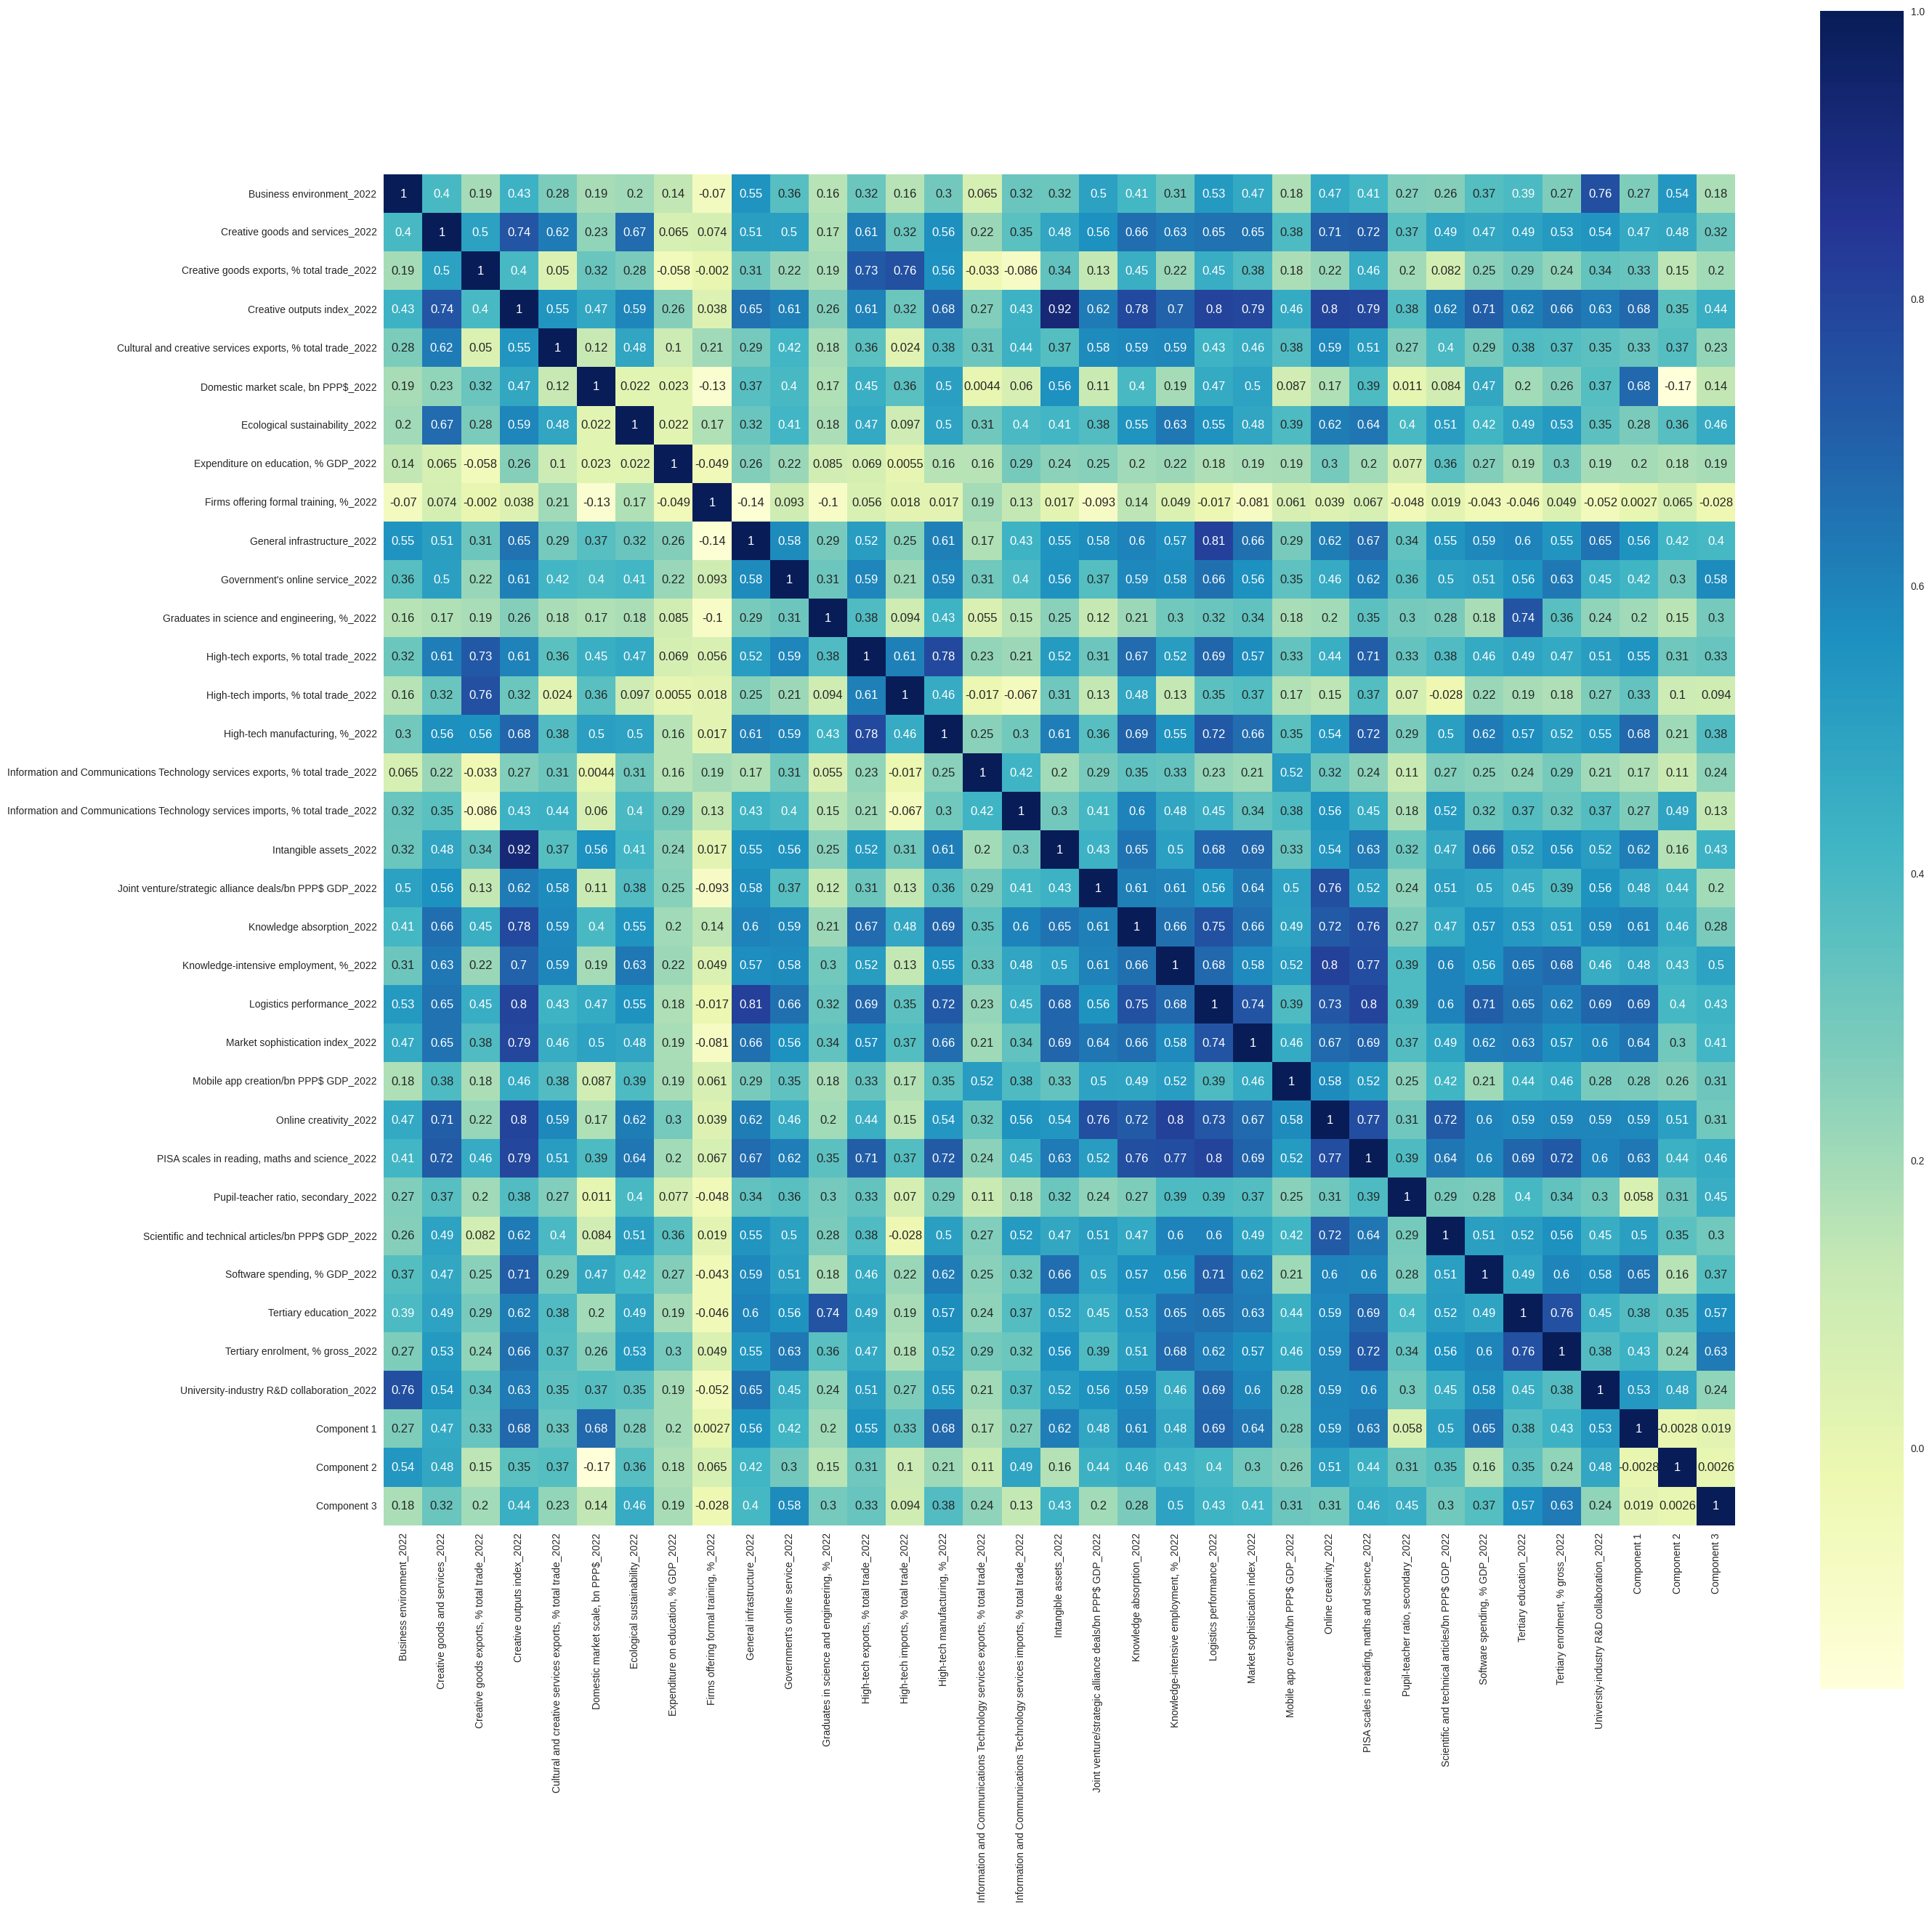

In [173]:
cor2 = dn.corr(numeric_only=True)
plt.figure(figsize=(30, 30))
sns.heatmap(cor2, square = True, cmap='YlGnBu', annot=True)
plt.show()

Также в анализ не были взяты категориальные переменные (Region, Region2, Euro area, European Union, OECD members, Least developed countries, Income, High income).

Высокая корреляция с другими переменными у Creative outputs index, Online creativity_2022, PISA scales in reading, maths and science_2022 без особой потери информации, так как есть другие переменные со схожим смыслом. Переменная Creative outputs index - это индекс, который собирает в себе несколько переменных, также включенных в датасет (такие как intangible assets, creative goods and services).   

In [174]:
dnn = dn.drop(['Creative outputs index_2022', 'Online creativity_2022', 'PISA scales in reading, maths and science_2022'], axis =1)

Можно отметить, что даже в новом датасете много переменных, которые описывают одну и ту же сферу и по смыслу повторяют друг друга. Некоторые переменные можно исключить без особой потери информации, а также избежать высокой корреляции, препятствующей проведению кластерного анализа.

В анализ не возьмем: Creative goods exports, % total; Firms offering formal training, %_2022; Government's online service_2022; Knowledge absorption_2022; Pupil-teacher ratio, secondary_2022; Tertiary enrolment, & gross_2022; Logistics performance_2022; Market sophistication index_2022; Cultural and creative services exports, % total trade_2022; High-tech exports, % total trade_2022; Software spending, % GDP_2022; Business enviroment_2022; Ecological sustainability_2022; Knowledge-intensive employment, %_2022; High-tech manufacturing, %_2022; Tertiary education_2022; Intangible assets_2022; General infrastructure_2022.

*Software spending включены по смыслу в собирательну переменную Intangible assets.


In [175]:
dnm = dnn.drop(['Creative goods exports, % total trade_2022', 'Firms offering formal training, %_2022', "Government's online service_2022", 'Knowledge absorption_2022', 'Pupil-teacher ratio, secondary_2022', 'Logistics performance_2022', 'Market sophistication index_2022',
                'Cultural and creative services exports, % total trade_2022', 'High-tech exports, % total trade_2022', 'Intangible assets_2022', 'Business environment_2022', 'Ecological sustainability_2022', 'Knowledge-intensive employment, %_2022',
                'High-tech manufacturing, %_2022', 'Tertiary education_2022', 'Tertiary enrolment, % gross_2022', 'Software spending, % GDP_2022', 'General infrastructure_2022'], axis =1)

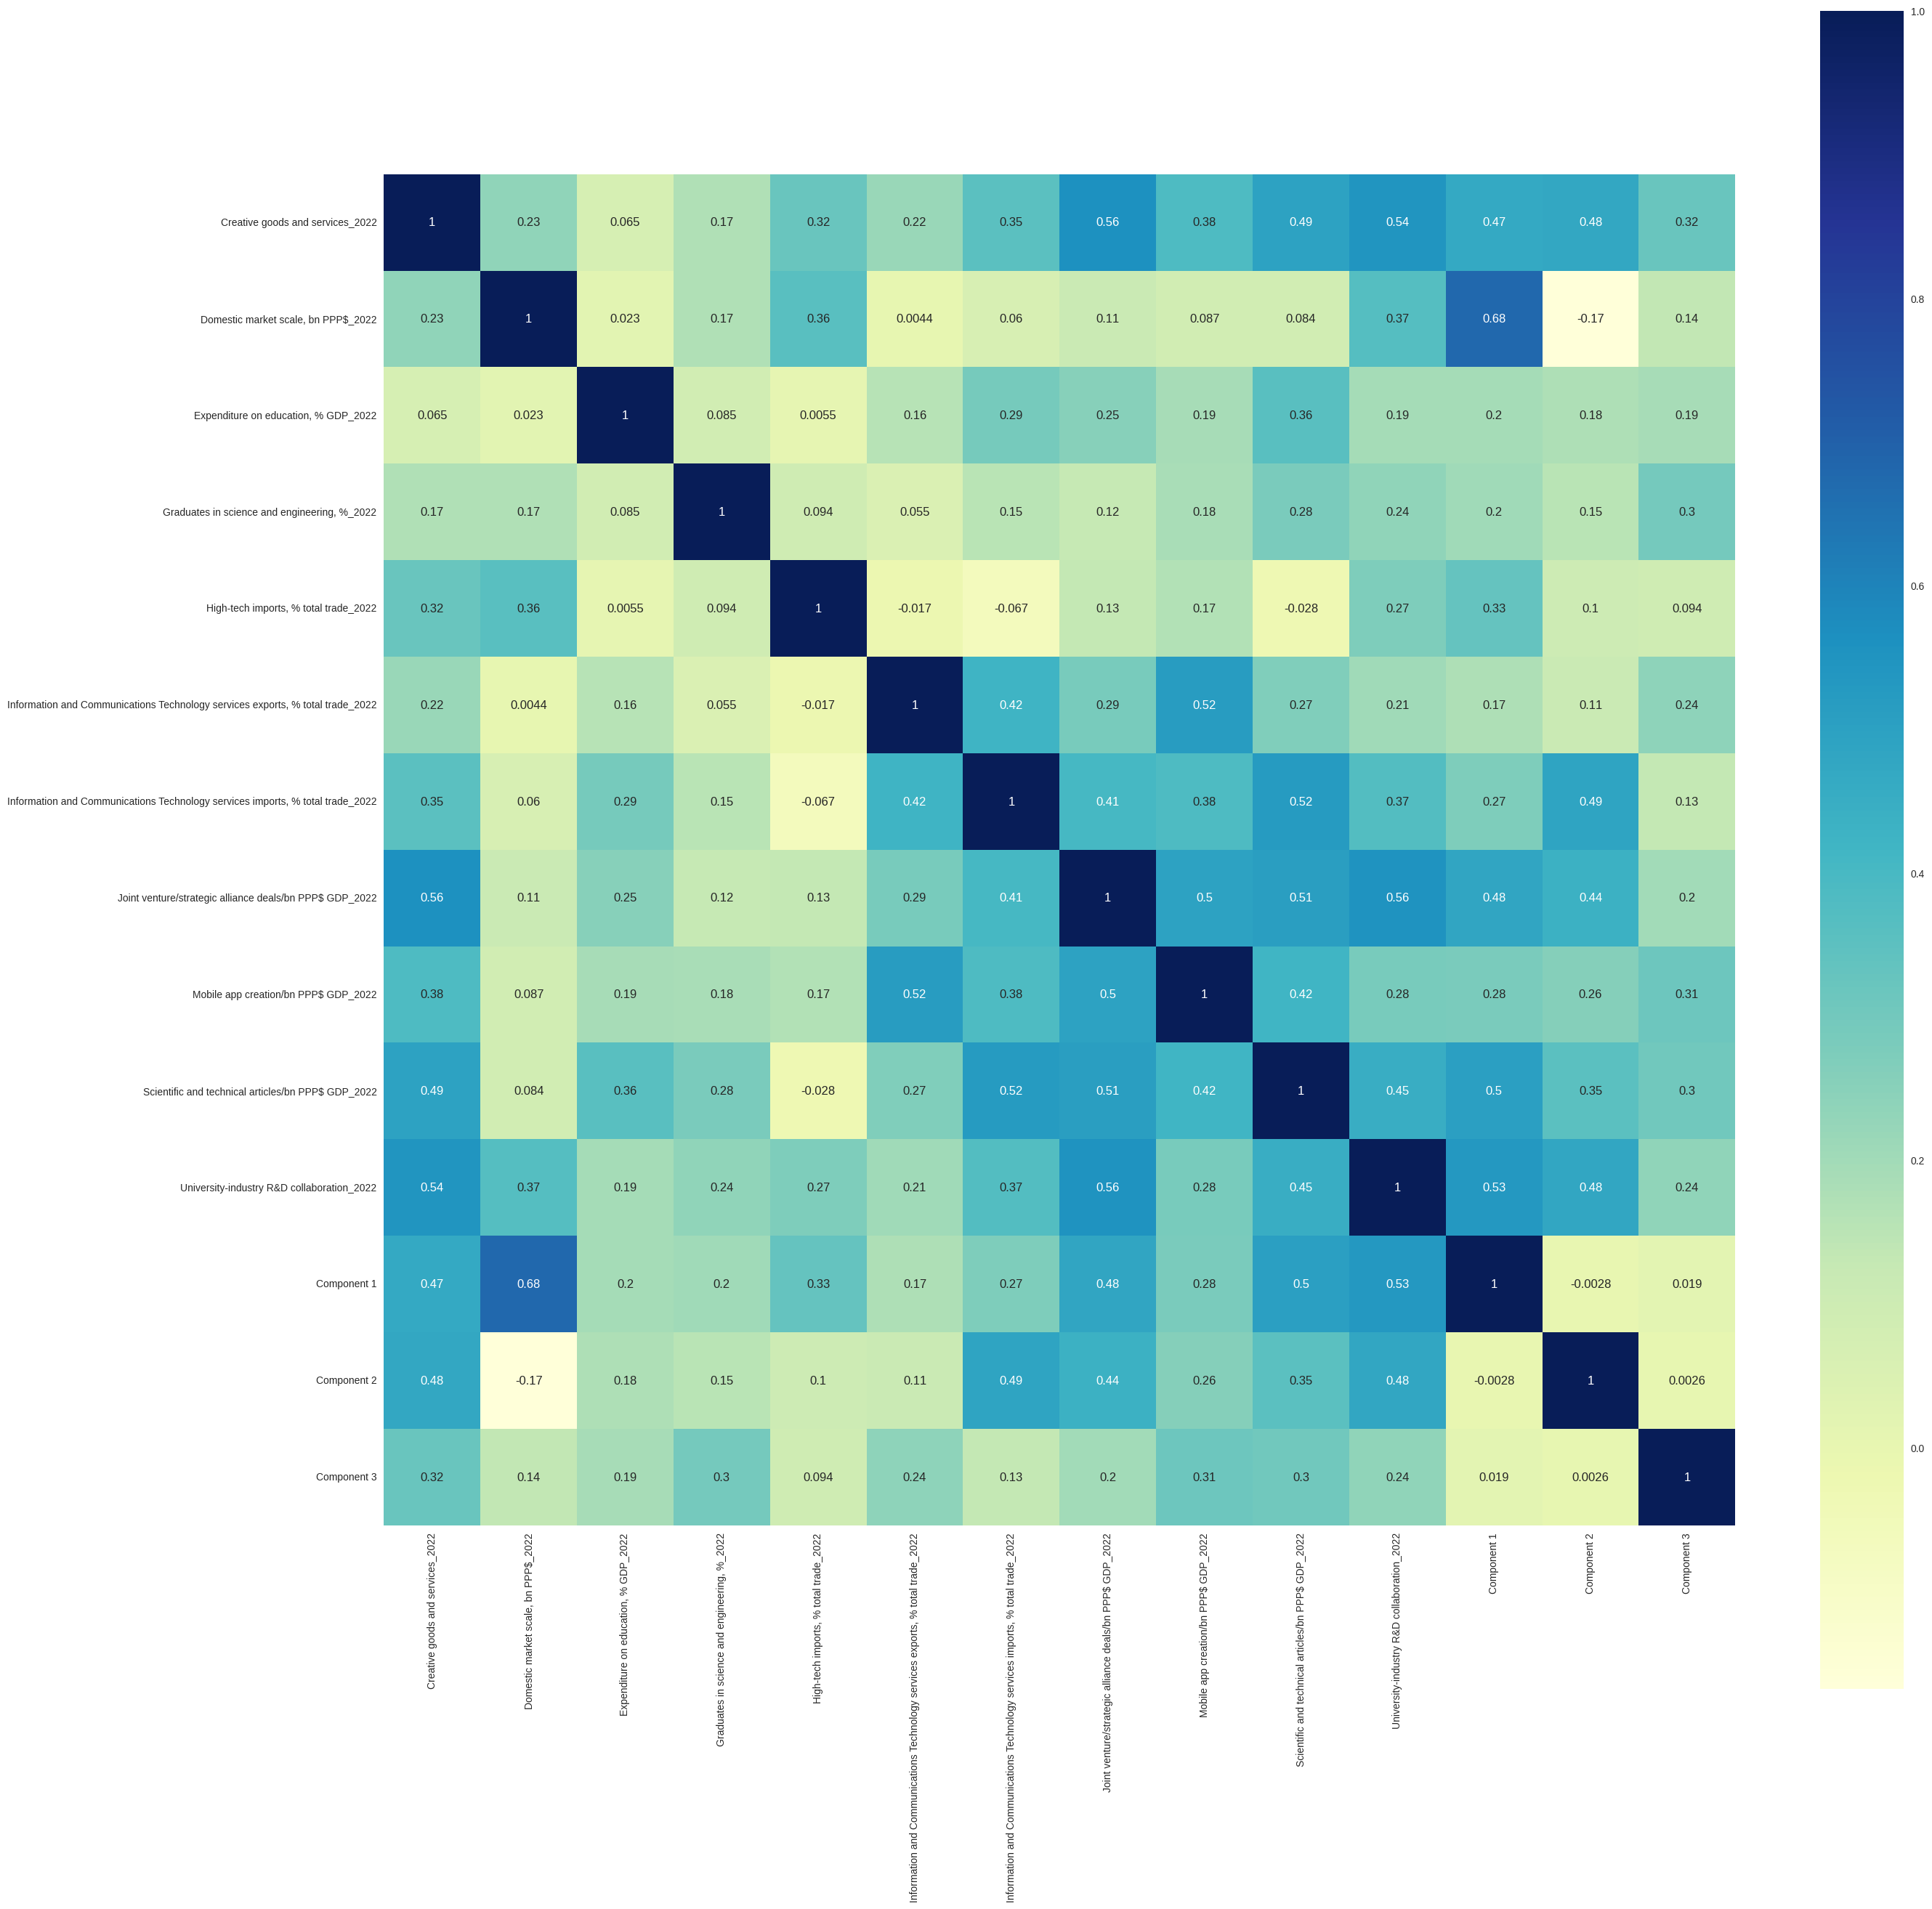

In [176]:
cor22 = dnm.corr(numeric_only=True)
plt.figure(figsize=(30, 30))
sns.heatmap(cor22, square = True, cmap='YlGnBu', annot=True)
plt.show()

После дополнительной обработки датасета избавились от высоких корреляций. Выше представлена тепловая диаграмма, показывающая корреляции между выбранными для последующего кластерного анализа переменными.

Кластерный анализ будем проводить с 14 переменными: комбинация из 11 переменных из исходного датасета и 3 созданными компонентами.

In [177]:
dnm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 14 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Creative goods and services_2022                                                132 non-null    float64
 1   Domestic market scale, bn PPP$_2022                                             132 non-null    float64
 2   Expenditure on education, % GDP_2022                                            132 non-null    float64
 3   Graduates in science and engineering, %_2022                                    132 non-null    float64
 4   High-tech imports, % total trade_2022                                           132 non-null    float64
 5   Information and Communications Technology services exports, % total trade_2022  132 non-null    float64
 6   Information and Co

In [178]:
dnm

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Component 1,Component 2,Component 3
0,1.2,3.4,25.5,0.0,14.4,8.2,44.2,1.9,0.0,4.2,38.5,-0.765280,0.207582,-0.920419
1,40.6,10.3,35.4,55.4,74.3,22.4,30.2,5.1,13.3,53.2,59.1,0.414501,0.847836,0.400567
2,9.1,30.9,13.9,5.9,18.9,13.8,27.8,3.5,0.6,27.1,47.0,-0.106007,-0.931004,0.010320
3,47.4,10.8,37.0,0.0,100.0,3.3,5.5,65.0,37.9,0.0,62.9,0.832383,0.657949,0.813999
4,4.0,26.6,27.3,99.8,11.8,1.2,8.0,0.0,0.5,62.9,27.7,0.352296,-2.616726,1.401620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.6,2.1,23.8,0.0,60.0,0.9,0.0,0.0,0.1,2.8,26.8,-0.781950,-0.246067,-0.063152
135,12.6,10.0,35.1,68.2,28.5,2.2,28.5,1.3,0.7,7.6,32.7,-0.029276,-0.382457,-0.173327
136,1.7,0.6,33.4,0.0,16.4,1.4,10.8,12.4,0.0,11.1,33.6,-1.141029,0.285898,0.443141
137,44.8,100.0,43.1,33.0,59.3,16.5,28.6,75.5,16.2,26.9,79.6,3.438655,-0.243142,-0.225545


##Задание 3

3. Выберите подходящий алгоритм кластеризации и обоснуйте свой выбор. Определите число кластеров, объясните своё решение. Опишите получившиеся кластеры с помощью описательной статистки. Нужно не просто рассчитать статистики в таблицах, но детально описать полученные результаты. Дайте названия кластерам и обоснуйте их.

####Иерархическая кластеризация

Выборка содержим 139 наблюдений, поэтому можно проводить иерархическую кластеризацию.

In [179]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [180]:
from scipy.stats.mstats import zscore

In [181]:
dnm.columns

Index(['Creative goods and services_2022',
       'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022', 'Component 1',
       'Component 2', 'Component 3'],
      dtype='object')

In [182]:
X = dnm [['Creative goods and services_2022', 'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022']] #создаем датасет с отобранными переменными
       #первоначально не берем в число переменных компоненты, чтобы провесит стандартизацию других переменных
       #а компоненты уже сформировались на стандартизированных данных

In [183]:
X_z = X.apply(lambda x: (x-x.mean()) / x.std() if x.std() != 0 else x, axis=0)
#z-стандартизация данных, так как все данные изначального датасета имеют разные шкалы

In [184]:
X_z = pd.concat([X_z, dnm[['Component 1', 'Component 2', 'Component 3']]], axis=1)
X_z

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Component 1,Component 2,Component 3
0,-1.215446,-0.485063,-0.585290,-1.337511,-0.656647,-0.516702,0.620399,-0.641427,-0.613320,-0.994451,-0.399007,-0.765280,0.207582,-0.920419
1,1.683033,-0.212988,-0.063631,0.634495,2.451017,0.140269,0.006610,-0.494361,0.399229,1.072887,0.948459,0.414501,0.847836,0.400567
2,-0.634279,0.599294,-1.196527,-1.127496,-0.423183,-0.257615,-0.098612,-0.567894,-0.567641,-0.028287,0.156986,-0.106007,-0.931004,0.010320
3,2.183278,-0.193272,0.020678,-1.337511,3.784355,-0.743404,-1.076291,2.258519,2.272064,-1.171652,1.197021,0.832383,0.657949,0.813999
4,-1.009463,0.429740,-0.490443,2.214947,-0.791537,-0.840562,-0.966686,-0.728747,-0.575254,1.482136,-1.105446,0.352296,-2.616726,1.401620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-1.259585,-0.536323,-0.674867,-1.337511,1.709121,-0.854441,-1.317423,-0.728747,-0.605707,-1.053518,-1.164316,-0.781950,-0.246067,-0.063152
135,-0.376800,-0.224817,-0.079438,1.090120,0.074874,-0.794296,-0.067922,-0.669001,-0.560028,-0.851003,-0.778391,-0.029276,-0.382457,-0.173327
136,-1.178663,-0.595470,-0.169016,-1.337511,-0.552885,-0.831308,-0.843928,-0.158868,-0.613320,-0.703336,-0.719521,-1.141029,0.285898,0.443141
137,1.992007,3.323986,0.342104,-0.162851,1.672804,-0.132698,-0.063538,2.741077,0.620010,-0.036725,2.289385,3.438655,-0.243142,-0.225545


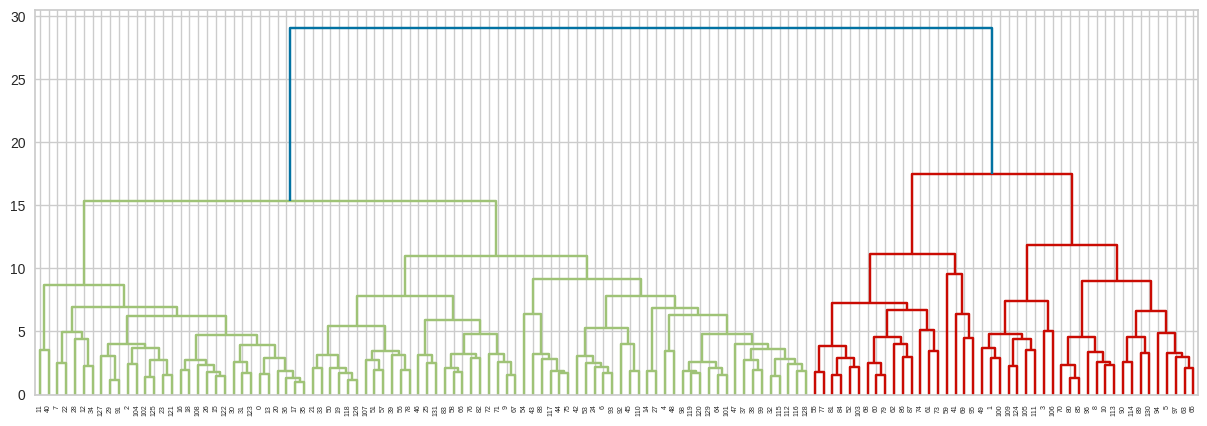

In [185]:
plt.figure(figsize=(15, 5))
dn = dendrogram(linkage(X_z[['Creative goods and services_2022', 'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022', 'Component 1',
       'Component 2', 'Component 3']].dropna(), 'ward'))
#Метод Варда

По виду дендрограммы можно предварительно предположить количество кластеров. Целесообразно рассмореть случай с 3 и 4 кластерами. Если возьмем 2 кластера, внутри этих кластеров будет наблюдаться серьезная гетерогенность (разнородность).

Если берем случай с 3 кластерами, то получается, что в один кластер ("оранжевая" часть) попадут 2 большие разнородные группы.

После уровня, на котором еще 4 кластера, начинаются значительные скачки расстояния. Если и дальше объединять кластеры, то будут объединены в один кластер группы, которые находятся на большом расстоянии друг от друга (например, две большие группы из "оранжевой секции").
Поэтому наиболее рационально разделить страны на 4 кластера.

Есть взять большее количество кластеров, то получим слишком большое число гомогенных групп.

In [186]:
X_z = X_z.dropna()

In [187]:
X_z = X_z.rename({'Component 1':'Knowledge and Research', 'Component 2':'Government Efficiency', 'Component 3':'Information Technology Infrastructure'}, axis='columns')

In [188]:
X_zk = X_z #для последующего проведения кластеризации методом k-средних

In [189]:
X_z1 = X_z

In [190]:
from sklearn.metrics import calinski_harabasz_score

In [191]:
Z = linkage(X_z1, method='ward', metric='euclidean')
labels = fcluster(Z, t=4, criterion='maxclust')
calinski_harabasz_score(X_z1, labels)

25.586427386499434

In [192]:
for k in range (2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(X_z1, labels)))

Число кластеров: 2, индекс 38.458955628000176
Число кластеров: 3, индекс 29.11414895032327
Число кластеров: 4, индекс 25.586427386499434
Число кластеров: 5, индекс 22.309223669108075
Число кластеров: 6, индекс 20.3167415413405
Число кластеров: 7, индекс 19.145728671481972
Число кластеров: 8, индекс 17.956894453573675
Число кластеров: 9, индекс 17.065335158811074


Результаты расчета индекса Калински-Харабаша с увеличением количества кластеров снижается. То есть с увеличением количества кластеров, снижается и качество кластеризации. Хотя наиболее высокое значение индекса достигается при 2 кластерах, при 3 и 4 значения находятся на высоком уровне.

In [193]:
labels = fcluster(Z, t=4, criterion='maxclust') #случай с 4 кластерами
X_z1['cluster_labels'] = labels
X_z1

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure,cluster_labels
0,-1.215446,-0.485063,-0.585290,-1.337511,-0.656647,-0.516702,0.620399,-0.641427,-0.613320,-0.994451,-0.399007,-0.765280,0.207582,-0.920419,1
1,1.683033,-0.212988,-0.063631,0.634495,2.451017,0.140269,0.006610,-0.494361,0.399229,1.072887,0.948459,0.414501,0.847836,0.400567,4
2,-0.634279,0.599294,-1.196527,-1.127496,-0.423183,-0.257615,-0.098612,-0.567894,-0.567641,-0.028287,0.156986,-0.106007,-0.931004,0.010320,1
3,2.183278,-0.193272,0.020678,-1.337511,3.784355,-0.743404,-1.076291,2.258519,2.272064,-1.171652,1.197021,0.832383,0.657949,0.813999,4
4,-1.009463,0.429740,-0.490443,2.214947,-0.791537,-0.840562,-0.966686,-0.728747,-0.575254,1.482136,-1.105446,0.352296,-2.616726,1.401620,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-1.259585,-0.536323,-0.674867,-1.337511,1.709121,-0.854441,-1.317423,-0.728747,-0.605707,-1.053518,-1.164316,-0.781950,-0.246067,-0.063152,1
135,-0.376800,-0.224817,-0.079438,1.090120,0.074874,-0.794296,-0.067922,-0.669001,-0.560028,-0.851003,-0.778391,-0.029276,-0.382457,-0.173327,2
136,-1.178663,-0.595470,-0.169016,-1.337511,-0.552885,-0.831308,-0.843928,-0.158868,-0.613320,-0.703336,-0.719521,-1.141029,0.285898,0.443141,2
137,1.992007,3.323986,0.342104,-0.162851,1.672804,-0.132698,-0.063538,2.741077,0.620010,-0.036725,2.289385,3.438655,-0.243142,-0.225545,4


In [194]:
X_z1['cluster_labels'].value_counts()

,count
cluster_labels,
2,57
1,31
4,25
3,19


Самый многочисленный кластер - 2. Распределение между тремя другими кластерами более-менее равномерное. В датасете также большое количество стран с низким уровнем по всем показателям (1 кластер). Они по количеству на втором месте. 3 кластер включает наименьшее количество стран.

In [195]:
clusters = X_z1.groupby('cluster_labels').mean(numeric_only=True).T
clusters

cluster_labels,1,2,3,4
Creative goods and services_2022,-0.925219,-0.166687,1.009328,0.760228
"Domestic market scale, bn PPP$_2022",-0.417903,-0.395755,-0.116070,1.508734
"Expenditure on education, % GDP_2022",-0.395595,-0.023418,0.788884,-0.055621
"Graduates in science and engineering, %_2022",-0.924715,0.211467,0.340174,0.405970
"High-tech imports, % total trade_2022",-0.334483,-0.282194,-0.315052,1.297602
"Information and Communications Technology services exports, % total trade_2022",-0.368354,-0.053478,1.103811,-0.260206
"Information and Communications Technology services imports, % total trade_2022",-0.326449,-0.282672,1.385791,-0.003913
Joint venture/strategic alliance deals/bn PPP$ GDP_2022,-0.499253,-0.377451,1.310576,0.483624
Mobile app creation/bn PPP$ GDP_2022,-0.533996,-0.211292,1.002271,0.382176
Scientific and technical articles/bn PPP$ GDP_2022,-0.623991,-0.252119,1.568516,0.156508


Профили кластеров:

1 кластер: Характеризуется низкими значениями по всем показателям. В данный кластер входят страны с низким уровнем развития творческих отраслей, малый и неразвитый внутренний рынок (малая экономика, зависимая от более крупных экономик), низкие расходы на образование, недостаточное количество выпускников в области науки и техники, низкий уровень импорта высокотехнологичных товаров, ограниченные экспортно-импортные операции в сфере ИТ-услуг, небольшое число совместных предприятий и стратегических альянсов, низкий уровень создания мобильных приложений, малое количество научных публикаций, неактивное сотрудничество между университетами и промышленностью в области НИОКР, низкая эффективность правительства и слабая информационно-технологическая инфраструктура.

2 кластер: в этом кластере находятся страны, показатели которых по большинству переменных выше, чем в случае с 1 кластером, но все еще ниже, чем в 3 и 4 кластерах. Тем не менее, для них характерные наибольшие значения показателя Information Technology Infrastructure (компонента 3), который характеризует уровень использования, доступ к технологиям и развитие инфраструктуры). По Expenditure on education, % GDP_2022 и High-tech imports, % total trade_2022 занимает 2 место. Кластер со странами с наиболее высоким уровнем развития и использования технологий.

3 кластер: Данный кластер объединяет страны с наиболее сильно развитым сектором творческих отраслей, наиболее высоким процентом расходов на образование, большим количество выпускников в области науки и техники, высоким уровнем импорта высокотехнологичных товаров, наиболее интенсивными экспортными и импортными операции в сфере ИТ-услуг, большим количеством совместных предприятий и стратегических альянсов, активным созданием мобильных приложений, большим количеством научных публикаций. Характеризуются очень активным сотрудничеством между университетами и промышленностью в области исследований и разработок, высокой эффективностью правительства и хорошо развитая информационно-технологическая инфраструктура (на 3 месте, если сравнивать между кластерами, но значение мало отличается от 2 в рейтинге по уровню развития инфрастраструктуры). Рынок страны достаточно большой и независимый (способный к самообеспечению, но меньше, чем страны 4 кластера).

4 кластер: Наиболее высокие, по сравнению с другими кластерами, показатели Domestic market scale, bn PPP$_2022, Graduates in science and engineering, %_2022, High-tech imports, % total trade_2022, Knowledge and Research (компонента 1). Компонента Knowledge and Research включает характеристики количества работников в научной сфере, расходы на исследования и разработки, количество высокоцитируемых статей, уровень развития человеческого капитала.  По другим показателям также имеет высокие значения, но несколько ниже, чем кластер 3. Довольно развита информационно-технологическая инфраструктура. Можно охарактеризовать круг стран, входящих в этот кластер, как страны с развитой экономикой,ориентированной на науку и технологии.

Названия кластеров в Задании 5


####Метод k-средних

Проверим разделение на кластеры методом KMeans. Работаем с выборкой среднего размера, поэтому этот метод может быть применен.

In [196]:
X_zk = X_zk.drop(["cluster_labels"], axis = 1)

In [197]:
from sklearn.cluster import KMeans
for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(X_zk)
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(X_zk, labels)))

Число кластеров: 2, индекс 42.78164884450171
Число кластеров: 3, индекс 30.507830810533775
Число кластеров: 4, индекс 25.704807675047086
Число кластеров: 5, индекс 22.443903927205074
Число кластеров: 6, индекс 21.277269824990423
Число кластеров: 7, индекс 18.145280816592347
Число кластеров: 8, индекс 17.081306400381727
Число кластеров: 9, индекс 18.13003918275246
Число кластеров: 10, индекс 17.54112537355855
Число кластеров: 11, индекс 15.401907454335175
Число кластеров: 12, индекс 15.70510395187071
Число кластеров: 13, индекс 15.009134171228368
Число кластеров: 14, индекс 14.070693751453222


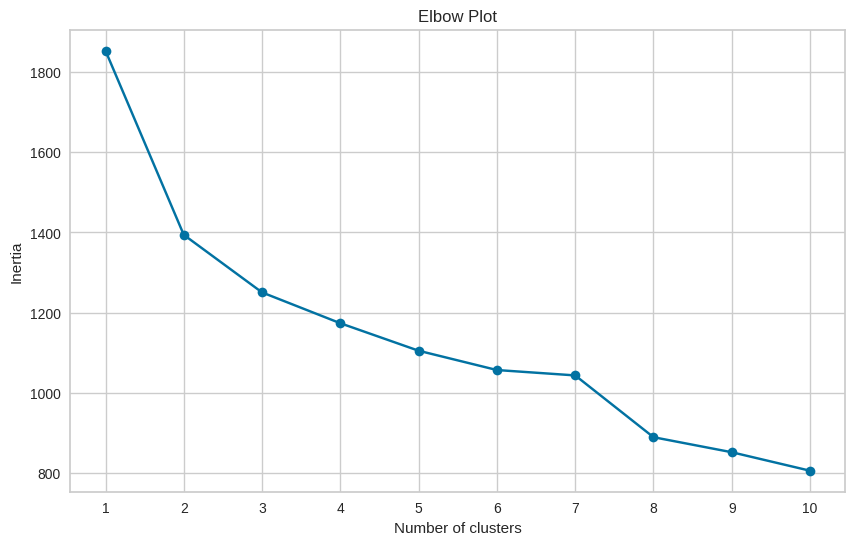

In [198]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_zk)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

На оси ординат - значения суммы квадратов внутрикластерных расстояний (WCSS). Показывает, насколько хорошо точки данных кластеризованы вокруг соответствующих им центроидов.

Из диаграммы можно предположить, что оптимальное количество кластеров 3-4, так как до этого значения с увеличением количества кластеров происходило стремительное снижение. После этого значения темп снижения сокращается. Это говорит о том, что большее количество кластеров избыточно.

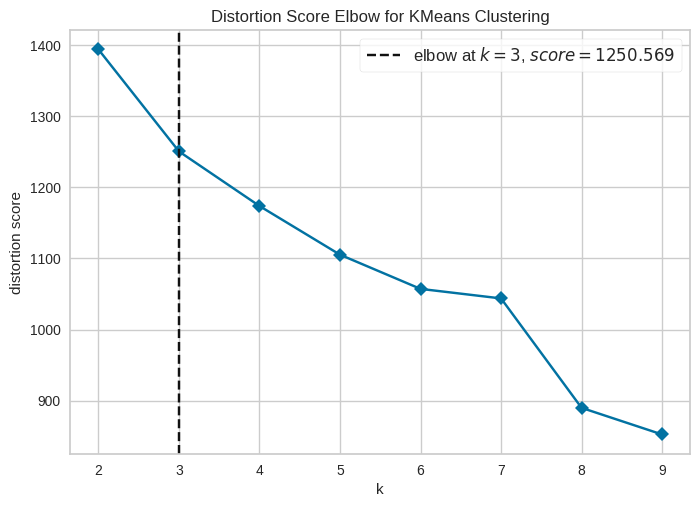

In [199]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X_zk)
visualizer.show()
plt.show()

На этом графике по оси ординат расположены значение искажения - среднее квадратов расстояний от центров кластеров соответствующих кластеров. Аналогично предыдущему графику, смотрим, в какой момент скорость снижения инерции начинает замедляться.

Замедление также происходит прилизительно после 3 или 4 кластера. Оптимальное значение кластеров может быть 3 или 4.

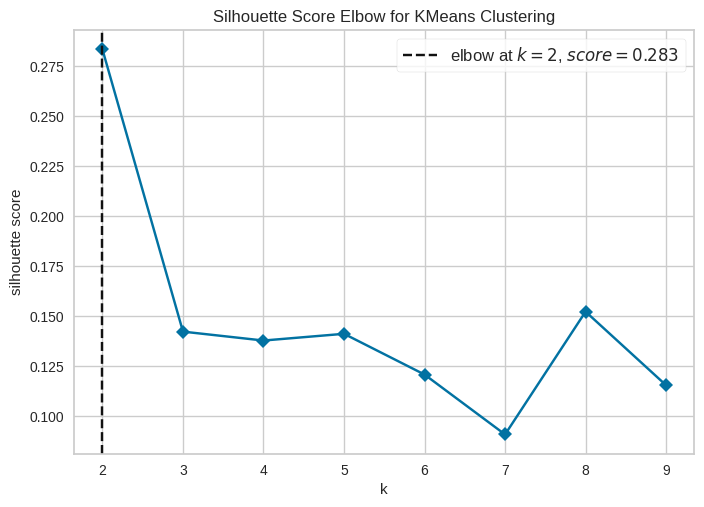

In [200]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X_zk)
visualizer.show()
plt.show()

Silhoutte score - метрика, направленная на определение количества наиболее четко определенных кластеров. Если метрика приближена к 1, объект соответсвует своему кластеру (похож на другие содержащиеся в нем объекты) и "не похож" на объекты из соседних кластеров.

Наибольшее значение коэффициента силуэта в случае с 2 кластерами.

По результатам кластеризации методом K-средних оставим **4 кластера**.

In [201]:
kmeans_model = KMeans(n_clusters=4).fit_predict(X_zk)

In [202]:
X_zk['Clusters_k-means'] = kmeans_model
X_zk

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure,Clusters_k-means
0,-1.215446,-0.485063,-0.585290,-1.337511,-0.656647,-0.516702,0.620399,-0.641427,-0.613320,-0.994451,-0.399007,-0.765280,0.207582,-0.920419,1
1,1.683033,-0.212988,-0.063631,0.634495,2.451017,0.140269,0.006610,-0.494361,0.399229,1.072887,0.948459,0.414501,0.847836,0.400567,0
2,-0.634279,0.599294,-1.196527,-1.127496,-0.423183,-0.257615,-0.098612,-0.567894,-0.567641,-0.028287,0.156986,-0.106007,-0.931004,0.010320,1
3,2.183278,-0.193272,0.020678,-1.337511,3.784355,-0.743404,-1.076291,2.258519,2.272064,-1.171652,1.197021,0.832383,0.657949,0.813999,0
4,-1.009463,0.429740,-0.490443,2.214947,-0.791537,-0.840562,-0.966686,-0.728747,-0.575254,1.482136,-1.105446,0.352296,-2.616726,1.401620,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-1.259585,-0.536323,-0.674867,-1.337511,1.709121,-0.854441,-1.317423,-0.728747,-0.605707,-1.053518,-1.164316,-0.781950,-0.246067,-0.063152,1
135,-0.376800,-0.224817,-0.079438,1.090120,0.074874,-0.794296,-0.067922,-0.669001,-0.560028,-0.851003,-0.778391,-0.029276,-0.382457,-0.173327,2
136,-1.178663,-0.595470,-0.169016,-1.337511,-0.552885,-0.831308,-0.843928,-0.158868,-0.613320,-0.703336,-0.719521,-1.141029,0.285898,0.443141,1
137,1.992007,3.323986,0.342104,-0.162851,1.672804,-0.132698,-0.063538,2.741077,0.620010,-0.036725,2.289385,3.438655,-0.243142,-0.225545,0


По сравнению с результатами, которые были получены иерархическим методом,

In [203]:
X_zk.columns

Index(['Creative goods and services_2022',
       'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure',
       'Clusters_k-means'],
      dtype='object')

In [204]:
X_zk.groupby('Clusters_k-means').mean(numeric_only=True) #профиль кластеров в результате применения метода k-средние

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure
Clusters_k-means,,,,,,,,,,,,,,
0,0.692240,1.758211,-0.060996,0.444704,1.326146,-0.101364,-0.031653,0.190621,0.290223,-0.047464,0.747469,1.160196,-0.146442,0.315171
1,-0.754436,-0.444036,-0.351057,-0.795777,-0.391931,-0.426925,-0.452376,-0.492610,-0.521418,-0.652306,-0.674201,-0.416640,-0.355140,-1.151452
2,-0.114110,-0.344343,0.031217,0.365450,-0.206688,0.075883,-0.150857,-0.355626,-0.135595,-0.079091,-0.226486,-0.498504,-0.120010,0.655563
3,1.096716,-0.175134,0.729397,0.304878,-0.139654,0.825925,1.346864,1.678300,1.101162,1.611872,1.137170,1.010383,1.224169,0.298163


По результатам разделения на кластеры методом k-средних были выделены следующие 4 кластера:

1 кластер (0): Страны со средним показателями по всем переменным. Значения по большинству переменных выше, чем в странах 1 кластера, но ниже, чем в 3 и 4 кластерах. Но для них характерны наибольшие значения показателя Information Technology Infrastructure (компонента 3). По Expenditure on education, % GDP_2022 и High-tech imports, % total trade_2022 занимает 2 место. Кластер со странами с наиболее высоким уровнем развития и использования технологий.

2 кластер (1): Страны с самыми низкими значениями по всем показателям.

3 кластер (2): Большие экономики, с самым высоким показателем Domestic market scale. Наибольшие значения High-tech imports, Knowledge and Research, Graduates in science and engineering. Другие показатели также на высоком уровне, но ниже, чем у стран 4 кластера.

4 кластер (3): Самые высокие показатели по Creative goods and services, Expenditure on education, Graduates in science and engineering, Information and Communications Technology services exports/imports, Joint venture/strategic alliance deals, Mobile app creation, Scientific and technical articles, Mobile app creation, Scientific and technical articles, University-industry R&D collaboration_2022, Government Efficiency. Высокий уровень развития творческих отраслей, высокие расходы на образование, наиболее значительное количество выпускников в области науки и техники, значительные экспортно-импортные операции в сфере ИТ-услуг, большое число совместных предприятий и стратегических альянсов, высокий уровень создания мобильных приложений, нкибольшее количество научных публикаций, активное сотрудничество между университетами и промышленностью в области исследований и разработок, высокая эффективность правительства. Довольно большие экономики.

Если сравнить с результатами по иерахичекому методу, то можно сказать, что интерпретация кластеров не изменилась. Страны разделились на те же смысловые группы.

In [205]:
X_zk['Clusters_k-means'].value_counts()

,count
Clusters_k-means,
2,48
1,42
0,22
3,20


Изменилось распредление стран по кластерам. Резко сократилось количество стран с наиболее высоким уровнем развития и использования технологий (на 7) и возросло количество стран с самыми низкими показателями по всем категориям (на 8). Наполняемость двух других кластеров почти не изменилась. Количество стран с развитой экономикой, ориентированной на науку и технологии, сократилось на 2.

In [206]:
X_z = X_z.drop(['cluster_labels'], axis = 1)

In [207]:
X_z

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure
0,-1.215446,-0.485063,-0.585290,-1.337511,-0.656647,-0.516702,0.620399,-0.641427,-0.613320,-0.994451,-0.399007,-0.765280,0.207582,-0.920419
1,1.683033,-0.212988,-0.063631,0.634495,2.451017,0.140269,0.006610,-0.494361,0.399229,1.072887,0.948459,0.414501,0.847836,0.400567
2,-0.634279,0.599294,-1.196527,-1.127496,-0.423183,-0.257615,-0.098612,-0.567894,-0.567641,-0.028287,0.156986,-0.106007,-0.931004,0.010320
3,2.183278,-0.193272,0.020678,-1.337511,3.784355,-0.743404,-1.076291,2.258519,2.272064,-1.171652,1.197021,0.832383,0.657949,0.813999
4,-1.009463,0.429740,-0.490443,2.214947,-0.791537,-0.840562,-0.966686,-0.728747,-0.575254,1.482136,-1.105446,0.352296,-2.616726,1.401620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-1.259585,-0.536323,-0.674867,-1.337511,1.709121,-0.854441,-1.317423,-0.728747,-0.605707,-1.053518,-1.164316,-0.781950,-0.246067,-0.063152
135,-0.376800,-0.224817,-0.079438,1.090120,0.074874,-0.794296,-0.067922,-0.669001,-0.560028,-0.851003,-0.778391,-0.029276,-0.382457,-0.173327
136,-1.178663,-0.595470,-0.169016,-1.337511,-0.552885,-0.831308,-0.843928,-0.158868,-0.613320,-0.703336,-0.719521,-1.141029,0.285898,0.443141
137,1.992007,3.323986,0.342104,-0.162851,1.672804,-0.132698,-0.063538,2.741077,0.620010,-0.036725,2.289385,3.438655,-0.243142,-0.225545


####DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Теперь используем метод DBSCAN (Density-Based Spatial Clustering of Applications with Noise).
Метод принимает на входе два параметра - радиус окрестности точек данных (eps) и минимальное число соседей. Принцип метода заключается в выделении областей с высоким скоплением наблюдений. Наблюдения в областях с низкой концентрацией считаются выбросами.

Если расстояние между двумя точками меньше или равно  eps, они считаются соседями.

In [208]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [209]:
# Проверка наличия NaN в данных
X_z.isnull().sum()

,0
Creative goods and services_2022,0
"Domestic market scale, bn PPP$_2022",0
"Expenditure on education, % GDP_2022",0
"Graduates in science and engineering, %_2022",0
"High-tech imports, % total trade_2022",0
"Information and Communications Technology services exports, % total trade_2022",0
"Information and Communications Technology services imports, % total trade_2022",0
Joint venture/strategic alliance deals/bn PPP$ GDP_2022,0
Mobile app creation/bn PPP$ GDP_2022,0
Scientific and technical articles/bn PPP$ GDP_2022,0


In [210]:
k = 3  # Количество соседей (min_samples в DBSCAN должно быть >= k)
nbrs = NearestNeighbors(n_neighbors=k).fit(X_z)
distances, indices = nbrs.kneighbors(X_z)
distances = np.sort(distances, axis=0)
distances = distances[:, -1]

Для определения оптимального радиуса окрестности точек данных построим график K-расстояний (K-distance Graph).

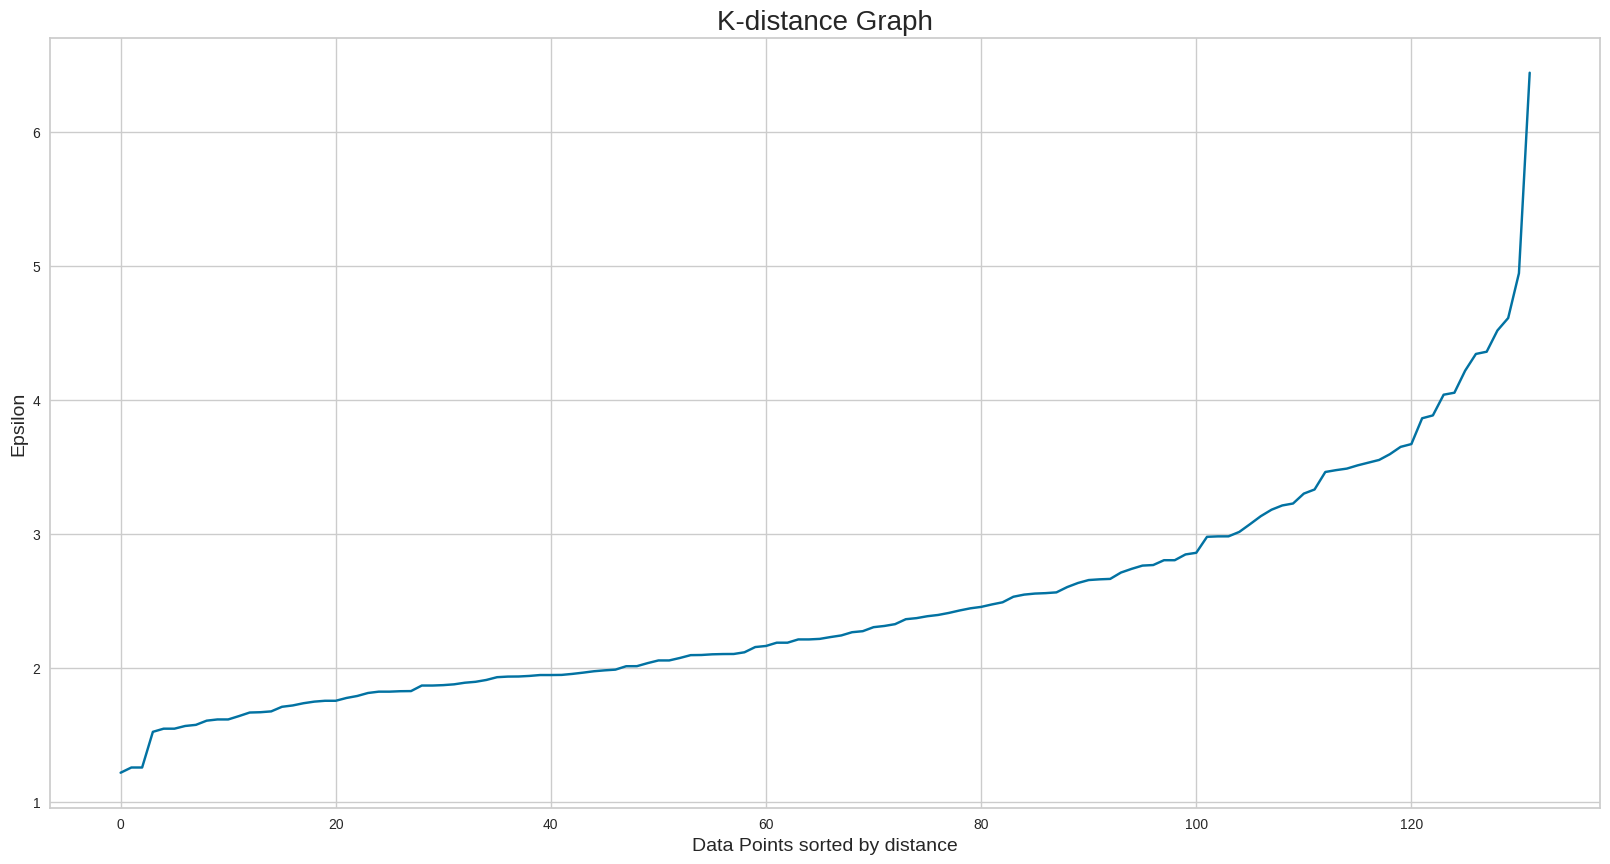

In [211]:
plt.figure(figsize=(20,10))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

С помощью визуализации мы подобрали коэффициент для eps (радиуса окрестности), для этого обычно ищется "колено" или "локоть" (в разных источниках называется по-разному) — точку, где кривая начинает резко подниматься, более стремительно. Эта точка указывает на оптимальное значение eps. В данном случае, колено, очевидно, находится на уровне 4. Это означает, что расстояние до k-го ближайшего соседа примерно равно 4.

In [212]:
from itertools import product

eps_values = np.arange(2,6,0.25) # рассматриваемые значения радиуса окрестности
min_samples = np.arange(1,5) # рассматриваемые значение минимального числа соседей

DBSCAN_params = list(product(eps_values, min_samples))

In [213]:
no_of_clusters = []
sil_score = []

In [214]:
for p in DBSCAN_params:
    try: # Добавлено для обработки ошибок, если DBSCAN не может сформировать кластеры
        DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(X_z)
        # Проверка, что хотя бы два кластера сформировались (или кластер и шум)
        if len(np.unique(DBS_clustering.labels_)) > 1:
            no_of_clusters.append(len(np.unique(DBS_clustering.labels_)))
            sil_score.append(silhouette_score(X_z, DBS_clustering.labels_))
        else:
            no_of_clusters.append(0) # Отмечаем как неудачный случай
            sil_score.append(-1) # Или присваиваем низкую оценку
    except ValueError as e: # Обработка исключений (например, когда все точки в одном кластере)
        print(f"Ошибка при параметрах {p}: {e}")
        no_of_clusters.append(0)
        sil_score.append(-1)

Часть кода выше написана с использованием ИИ. Прибегли к его помощи, так как при использовании кода из семинара, без уточнения, что должно получиться хотя бы 2 кластера, получали ошибку "Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)". Расчет silhouette score требует больше 1 кластера. Поэтому в тело цикла добавляем соответствующее условие, которое было написано с использованием искусственного интеллекта.

Построим тепловую карту, которая показывает, какое количество кластеров будет создавать метод DBSCAN при каждой соответствующей комбинации параметров.

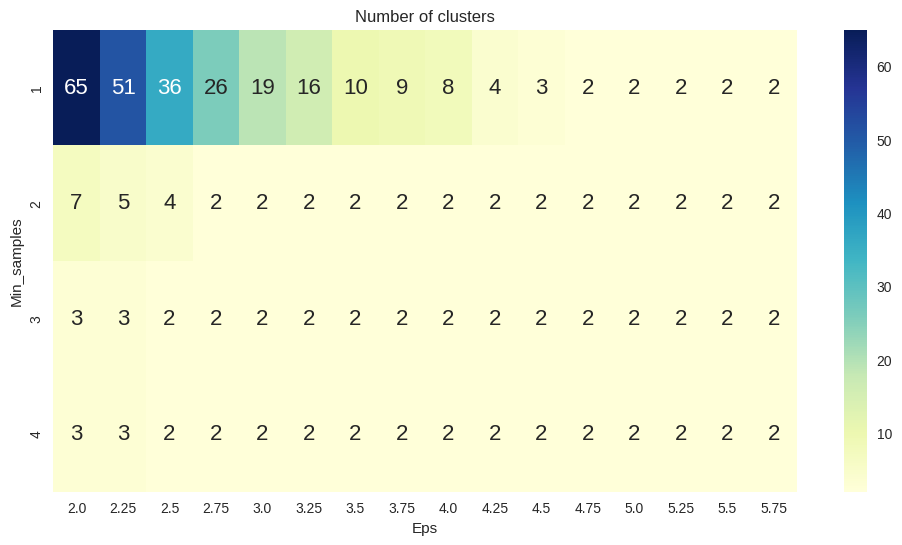

In [215]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['No_of_clusters'] = no_of_clusters

pivot_1 = pd.pivot_table(tmp, values='No_of_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot_1, annot=True,annot_kws={"size": 16}, cmap="YlGnBu", ax=ax)
ax.set_title('Number of clusters')
plt.show()

Можно отметить, что при заданных диапазонах радиуса окрестности точек и минимальном количестве соседей метод создаст от 2 до 65 кластеров. В случае большинства комбинаций параментров метод создаст 2 кластера, но также 3 и 4.

Построим вторую тепловую диаграмму, которая показывает значения коэффициента силуэта при различных комбинациях параметров.

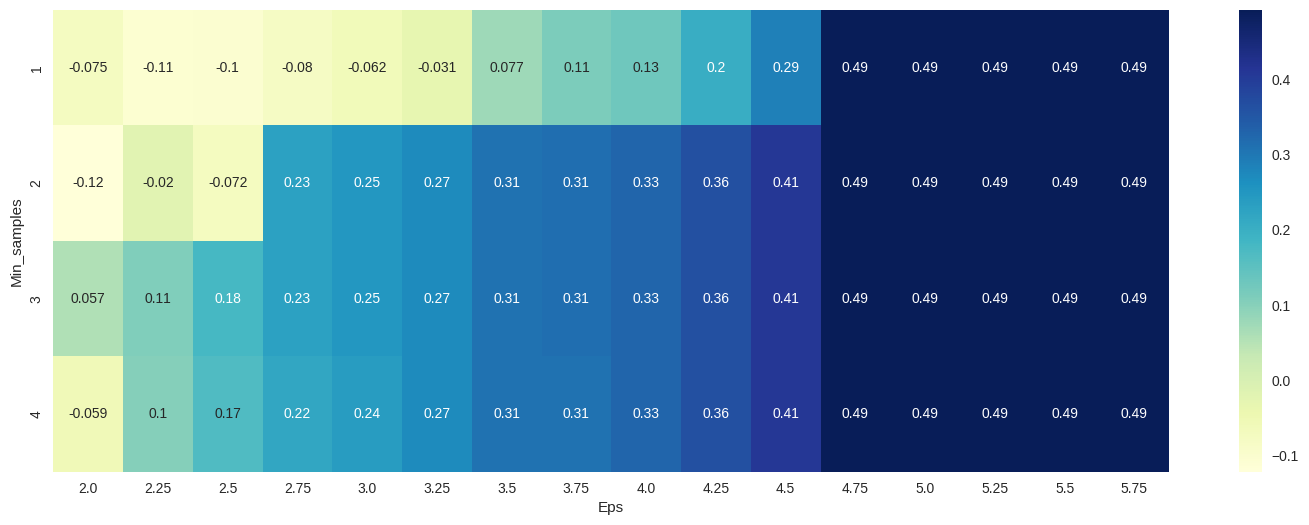

In [216]:
tmp = pd.DataFrame.from_records(DBSCAN_params, columns =['Eps', 'Min_samples'])
tmp['Sil_score'] = sil_score

pivot_1 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(18,6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 10}, cmap="YlGnBu", ax=ax)
plt.show()

Наиболее оптимальному числу кластеров соответсвует максимальное значение коэффициента силуэта. Наибольшие значения коэффициента силуаэта достигаются при радиусе больше 4.75. Количество кластеров в этой зоне - 2.

В результате предыдущих этапов кластерного анализа (иерархического и k-means) страны были разделены на 4 кластера. Коэффициент силуэта при этом количестве кластеров может принимать значение 0.2 в случае, когда eps = 4.25, а min_samples = 1. И при 3 кластерах может принимать значение 0.29, когда eps = 4.5, а min_samples = 1.



In [217]:
DBS_clustering = DBSCAN(eps=4.75, min_samples=4).fit(X_z)

DBSCAN_clustered = X_z.copy()
DBSCAN_clustered.loc[:,'Cluster'] = DBS_clustering.labels_

In [218]:
DBSCAN_clust_sizes = DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns = ["DBSCAN_size"]
DBSCAN_clust_sizes

,DBSCAN_size
Cluster,
-1,1
0,131


Здесь рассматривается случай с eps = 4, так как по K-Distance  Graph определили данный уровень радиуса окрестности как оптимальный. Значение коэффициента силуэта при данном eps наибольшее начиная с 4.75. В данном он выделяет 1 кластер на выбросы.

In [219]:
DBS_clustering = DBSCAN(eps=4.25, min_samples=1).fit(X_z)

DBSCAN_clustered = X_z.copy()
DBSCAN_clustered.loc[:,'Cluster'] = DBS_clustering.labels_

In [220]:
DBSCAN_clust_sizes = DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns = ["DBSCAN_size"]
DBSCAN_clust_sizes

,DBSCAN_size
Cluster,
0,129
1,1
2,1
3,1


В случае с 4 кластерами результаты не менее непоказательные, но уже нет отдельного кластера с выбросами. Распределение неравномерное.

Результаты кластеризации методом DBSCAN нельзя назвать удачными и показательными в данном случае.

##Задание 4

4. Проведите апостериорный анализ данных на основе категориальных переменных датасета. Например, рассмотрите как распределены страны разных регионов по кластерам или в какие кластеры в основном попали страны-члены ОЭСР?

Для удобства:
В иерархическом методе: кластеры 1, 2, 3, 4
В методе k-means им соответсувуют: 1, 0, 3, 2 (записаны в порядке соответствия иерархическому методу)

In [221]:
df_category = df[['Country', 'Region', 'Region2', 'Euro area', 'European Union', 'OECD members', 'Least developed countries', 'Income', 'High income']]

In [222]:
dnm = pd.concat([df_category, dnm], axis = 1)

In [223]:
dnm = dnm.rename({'Component 1':'Knowledge and Research', 'Component 2':'Government Efficiency', 'Component 3':'Information Technology Infrastructure'}, axis='columns')

In [224]:
dnm = pd.concat([dnm, X_z1['cluster_labels'], X_zk['Clusters_k-means']], axis = 1)

In [225]:
dnm

,Country,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income,Creative goods and services_2022,...,"Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure,cluster_labels,Clusters_k-means
0,Cote d'Ivoire,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,0,middle income,0,1.2,...,44.2,1.9,0.0,4.2,38.5,-0.765280,0.207582,-0.920419,1.0,1.0
1,Czechia,Europe & Central Asia,Europe,0,1,1,0,high income,1,40.6,...,30.2,5.1,13.3,53.2,59.1,0.414501,0.847836,0.400567,4.0,0.0
2,"Egypt, Arab Rep.",Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0,9.1,...,27.8,3.5,0.6,27.1,47.0,-0.106007,-0.931004,0.010320,1.0,1.0
3,"Hong Kong SAR, China",East Asia & Pacific,Asia-Pacific,0,0,0,0,high income,1,47.4,...,5.5,65.0,37.9,0.0,62.9,0.832383,0.657949,0.813999,4.0,0.0
4,"Iran, Islamic Rep.",Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0,4.0,...,8.0,0.0,0.5,62.9,27.7,0.352296,-2.616726,1.401620,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Paraguay,Latin America & Caribbean,Americas,0,0,0,0,middle income,0,0.6,...,0.0,0.0,0.1,2.8,26.8,-0.781950,-0.246067,-0.063152,1.0,1.0
135,Peru,Latin America & Caribbean,Americas,0,0,0,0,middle income,0,12.6,...,28.5,1.3,0.7,7.6,32.7,-0.029276,-0.382457,-0.173327,2.0,2.0
136,Trinidad and Tobago,Latin America & Caribbean,Americas,0,0,0,0,high income,1,1.7,...,10.8,12.4,0.0,11.1,33.6,-1.141029,0.285898,0.443141,2.0,1.0
137,United States,North America,Americas,0,0,1,0,high income,1,44.8,...,28.6,75.5,16.2,26.9,79.6,3.438655,-0.243142,-0.225545,4.0,0.0


####Апостериорный анализ кластеров, созданных иерархическим методом

 Рассмотрим, какие страны входят в каждый кластер по регионам их расположения, уровню развития, включены ли они в ОЭСР или ЕС. Иными словами, рассмотрим кластеры с точки зрения стран, которые в них включены. Сначала проанализируем кластеры в разбивке иерархического метода.

In [226]:
dnm.groupby('cluster_labels')['Income'].value_counts()

cluster_labels  Income       
1.0             middle income    18
                low income       13
2.0             middle income    40
                high income      17
3.0             high income      18
                middle income     1
4.0             high income      16
                middle income     9
Name: count, dtype: int64

<Axes: xlabel='cluster_labels'>

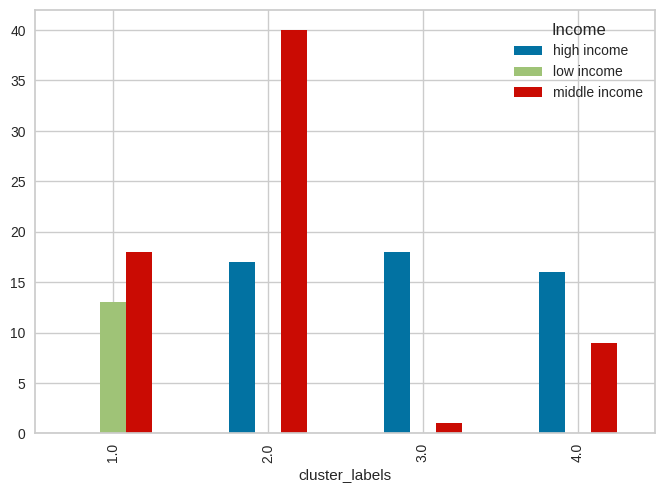

In [227]:
dnm.groupby(['cluster_labels'])['Income'].value_counts().unstack().plot(kind='bar')

На графике расположена графическая интерпретация кластеризации датасета на 4 кластера.
1 кластер (рабочее название - Тень прогресса, потому что низкие показатели по всем параметрам относительно максимального значения): преобладание людей со средним доходом и небольшое количество людей с низким доходом.
2 кластер (рабочее название - Равновесие пустоты, потому что, несмотря на высокие значения одного кластера, в среднем значение не такое большое): значительное преобладание людей со средним доходом (больше, чем во всех остальных кластерах); отсутствие людей с низким доходом и небольшое число людей с высоким доходом, которое приблизительно равно, и трети людей со средним доходом.
3 кластер (рабочее название - Феникс инноваций, потому что преобладание людей с высоким доходом дает надежду на метафорическое перераспределение дохода с помощью повсеместного распространения инноваций): преобладание людей с высоким доходом, практически отсутствие людей с средним доходом и полное отсутствие людей с низким доходом.
4 кластер (рабочее название - Оазис стабильности, потому что при отсутствии низкого дохода сохраняется не очень большой разрыв между средним и высоким доходом): практически равное количество людей с высоким доходом и людей со средним доходом при отсутствии людей с низким доходом.

In [228]:
dnm.groupby('cluster_labels')['Region'].value_counts()

cluster_labels  Region                    
1.0             Sub-Saharan Africa            18
                Latin America & Caribbean      5
                Middle East & North Africa     3
                South Asia                     3
                East Asia & Pacific            1
                Europe & Central Asia          1
2.0             Europe & Central Asia         22
                Latin America & Caribbean     11
                Middle East & North Africa    10
                Sub-Saharan Africa             9
                East Asia & Pacific            4
                South Asia                     1
3.0             Europe & Central Asia         15
                Middle East & North Africa     2
                East Asia & Pacific            1
                South Asia                     1
4.0             East Asia & Pacific           11
                Europe & Central Asia          9
                Latin America & Caribbean      2
                North America                  2
                Middle East & North Africa     1
Name: count, dtype: int64

<Axes: xlabel='cluster_labels'>

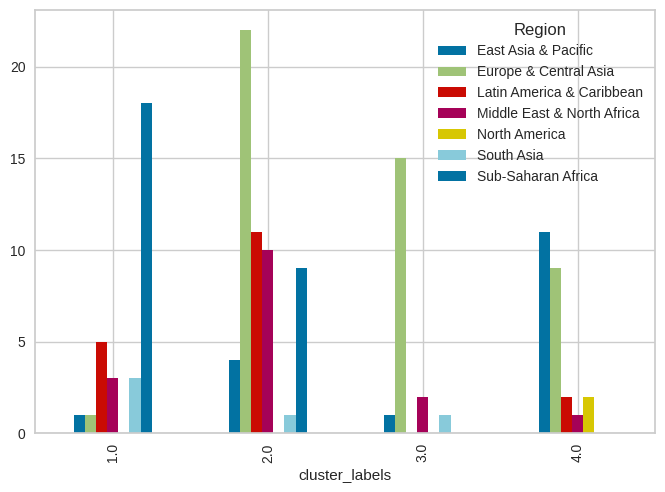

In [229]:
dnm.groupby(['cluster_labels'])['Region'].value_counts().unstack().plot(kind='bar')

На столбчатой диаграмме приведена графическая интерпертация кластеризации по регионам.
1. кластер представлен доминирующим регионом, а именно, странами Африки к Югу от Сахары с незначительным присутствием ЛАТАМа (Латинской Америки) и Ближнего Востока вместе с Северной Африкой.
2. кластер объединяет страны Европы и центральной Азии, а также (с большшим отрывом) страны ЛАТАМа, Ближнего Востока и Северной Африки
3. кластер, по большей части, представляет собой только страны Европы и ценральной Азии, поскольку, почти кратко превосходит остальные перменные (страны южной и восточной Азии, Ближний Восток и Северную Африку)
4. кластер, предаствлен, в свою очередь, двумя группами, близкими по значению: восточная Азия и Океания + Европа и центральная Азия; ЛАТАМ и страны Карибского бассейна + Ближний Восток и северная Африка.

Общие выводы по итогам графической интерпретации кластеризации:
Кластеры 1 и 4 включают больше развивающихся стран (ЛАТАМ + Африка южнее Сахары), тогда как кластеры 2 и 3 — развитые (Европа и центральная Азия).
Северная Америка представлена только в кластере 4, что может говорить о ее уникальных характеристиках, которые могут стать объектами дальнейшего исследования, при необходимости

In [230]:
dnm.groupby(['cluster_labels'])['OECD members'].value_counts()

cluster_labels  OECD members
1.0             0               31
2.0             0               49
                1                8
3.0             1               16
                0                3
4.0             1               14
                0               11
Name: count, dtype: int64

<Axes: xlabel='cluster_labels'>

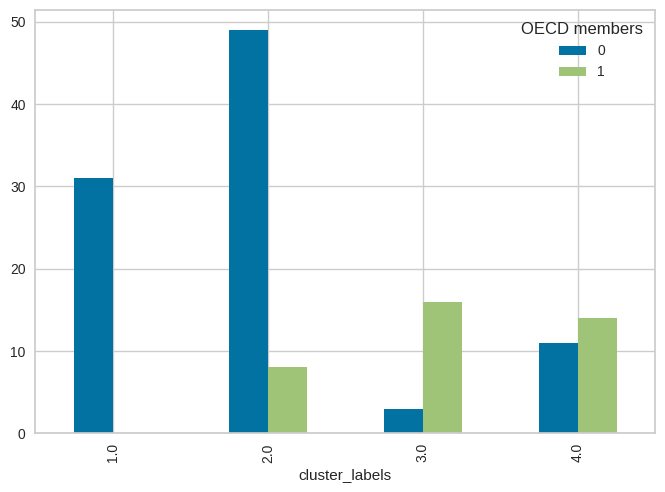

In [231]:
dnm.groupby(['cluster_labels'])['OECD members'].value_counts().unstack().plot(kind='bar')

По итогам графического представления кластерного анализа можно сделать следущие выводы:

Среди стран 1 и 2 кластера много таких, которые не входят в состав Организации экономического сотрудничества и развития. В 1 кластере нет ни одной страны-члена ОЭСР. Во втором кластере их подавляющее большинство. Только 8 стран из этого кластера входит в ОЭСР. В 3 кластере большая часть - страны, входящие в ОЭСР. 4 кластер почти в равной степени разделился на членов и не-членов ОЭСР.

In [232]:
dnm.groupby(['cluster_labels'])['Euro area'].value_counts(normalize=True).to_frame()
#в процентах по оси ординат

proportion
cluster_labels Euro area            
1.0            0            1.000000
2.0            0            0.912281
               1            0.087719
3.0            1            0.578947
               0            0.421053
4.0            0            0.840000
               1            0.160000

2 кластер почти на 9% состоит из стран Еврозоны. Наибольшая их доля приходится на 3 кластер, их доля составила 57,9%. В 3 кластере на них приходится 16% стран.

<Axes: xlabel='cluster_labels'>

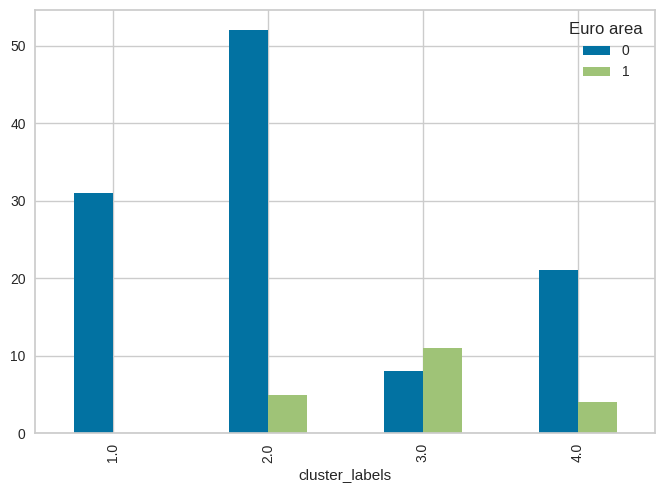

In [233]:
dnm.groupby(['cluster_labels'])['Euro area'].value_counts().unstack().plot(kind='bar')

Страны Еврозоны главным образом вошли в состав 3 кластера. Есть небольшое число тех стран Еврозоны, которые попали во 2 и 4 кластеры. Ни одна страна Еврозона не входит в состав 1 кластера (кластера стран с самыми низкими показателями по всем переменным).

In [234]:
dnm.groupby(['cluster_labels'])['Least developed countries'].value_counts(normalize=True).to_frame()
#в процентах

proportion
cluster_labels Least developed countries            
1.0            1                            0.612903
               0                            0.387097
2.0            0                            0.929825
               1                            0.070175
3.0            0                            1.000000
4.0            0                            1.000000

In [253]:
dnm.groupby(['cluster_labels'])['Least developed countries'].value_counts()
#в ячейках представлено количество

cluster_labels  Least developed countries
1.0             1                            19
                0                            12
2.0             0                            53
                1                             4
3.0             0                            19
4.0             0                            25
Name: count, dtype: int64

<Axes: xlabel='cluster_labels'>

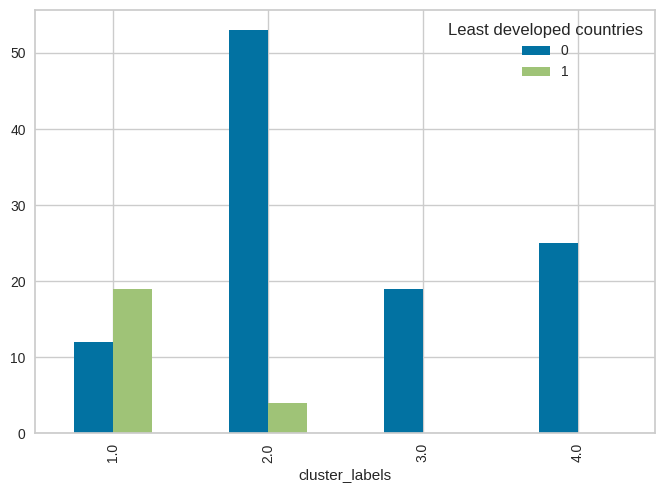

In [235]:
dnm.groupby(['cluster_labels'])['Least developed countries'].value_counts().unstack().plot(kind='bar')
#по оси ординат - количество

Все наименее развитые страны, присутсвтующие в датасете, вошли в состав первого кластера. 1 кластер в подавляющем большинстве представлен странами данной категории - на 61,3%. Также наименее развитые страны попали во 2 кластер. На них приходится 7% в этом кластере.

Рассчитаем описательные статистики по кластерам

In [236]:
dnm.columns

Index(['Country', 'Region', 'Region2', 'Euro area', 'European Union',
       'OECD members', 'Least developed countries', 'Income', 'High income',
       'Creative goods and services_2022',
       'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure',
       'cluster_labels', 'Clusters_k-means'],
      dtype='object')

In [237]:
dnm.groupby('cluster_labels')[['Creative goods and services_2022',
       'Domestic market scale, bn PPP$_2022',
       'Expenditure on education, % GDP_2022',
       'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022',
       'Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022',
       'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022',
       'Scientific and technical articles/bn PPP$ GDP_2022',
       'University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure',]].mean()

,Creative goods and services_2022,"Domestic market scale, bn PPP$_2022","Expenditure on education, % GDP_2022","Graduates in science and engineering, %_2022","High-tech imports, % total trade_2022","Information and Communications Technology services exports, % total trade_2022","Information and Communications Technology services imports, % total trade_2022",Joint venture/strategic alliance deals/bn PPP$ GDP_2022,Mobile app creation/bn PPP$ GDP_2022,Scientific and technical articles/bn PPP$ GDP_2022,University-industry R&D collaboration_2022,Knowledge and Research,Government Efficiency,Information Technology Infrastructure
cluster_labels,,,,,,,,,,,,,,
1.0,5.145161,5.103226,29.100000,11.596774,20.609677,11.406452,22.603226,4.993548,1.041935,12.980645,31.958065,-0.318993,-0.499532,-1.317581
2.0,15.456140,5.664912,36.163158,43.515789,21.617544,18.212281,23.601754,7.643860,5.280702,21.794737,40.905263,-0.568932,-0.107957,0.405516
3.0,31.442105,12.757895,51.578947,47.131579,20.984211,43.226316,61.657895,44.373684,21.221053,64.947368,60.810526,0.890830,1.113653,0.303254
4.0,28.056000,53.964000,35.552000,48.980000,52.068000,13.744000,29.960000,26.380000,13.076000,31.480000,56.380000,1.187881,0.042597,0.318874


Из этапа описания кластеров было рассмотрено соотношение по переменным. Соотношение средних значений будет таким же.

Рассмотрев средние значения показателей по каждому кластеру, можно отметить, что в 1 кластере, в который входят страны с наиболее низкими значениями по всем категориям, между 1 и 2 кластерами не очень сильные различия в проценте расходов на образование. В среднем импорт высокотехнологичной продукции у стран 1 кластера почти на том же уровне, что у 2 и 3 кластеров. Импорт ИКТ-услуг у стран 1 кластера в среднем почти совпадает с уровнем импорта стран 2 кластера. Можно предположить, что страны 1 кластера все-таки стремятся к повышению уровня за счет развития человеческого капитала и получения доступа к технологиям.

####Тест ANOVA

Проведем тест ANOVA для проверки статистической значимости полученных результатов. Проверим, что средние значения
анализируемых переменных значимо различаются по кластерам.

Гипотезы:

H0: Cредние значения переменной Creative goods and services_2022 для стран, относящихся к 4 разным кластерам, не отличаются.

H1: Cредние значения переменной Creative goods and services_2022 для стран, относящихся к 4 разным кластерам, отличаются.

In [238]:
cluster_1 = dnm[dnm['cluster_labels']== 1.0]['Creative goods and services_2022']
cluster_2 = dnm[dnm['cluster_labels']== 2.0]['Creative goods and services_2022']
cluster_3 = dnm[dnm['cluster_labels']== 3.0]['Creative goods and services_2022']
cluster_4 = dnm[dnm['cluster_labels']== 4.0]['Creative goods and services_2022']

In [239]:
from scipy import stats

In [240]:
stats.f_oneway(cluster_1.dropna(), cluster_2.dropna(), cluster_3.dropna(), cluster_4.dropna())

F_onewayResult(statistic=38.25067016960665, pvalue=1.0234624769481058e-17)

In [241]:
print(1.0234624769481058e-17<0.05)

True


Значение p-value < 0.05, следовательно, гипотеза H0 отклоняется. Значит, средние значения по кластерам отличаются. Проведем апостериорный тест, чтобы понять, между какими парами кластеров есть различия в значениях по данной переменной.

####Апостериорный тест

In [242]:
cleanTukey1 = dnm.filter(items=['Creative goods and services_2022', 'cluster_labels']).dropna()
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
mc1 = MultiComparison(cleanTukey1['Creative goods and services_2022'], cleanTukey1['cluster_labels'])
result1 = mc1.tukeyhsd()
print(result1)
print(mc1.groupsunique)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   1.0    2.0   10.311 0.0001   4.5101 16.1119   True
   1.0    3.0  26.2969    0.0  18.7234 33.8705   True
   1.0    4.0  22.9108    0.0  15.9235 29.8982   True
   2.0    3.0   15.986    0.0      9.1 22.8719   True
   2.0    4.0  12.5999    0.0   6.3644 18.8354   True
   3.0    4.0  -3.3861 0.6815 -11.2975  4.5253  False
-----------------------------------------------------
[1. 2. 3. 4.]


По результатам апостериорного теста можно сделать вывод, что уровень развития творческих отраслей производства значимо различается между всеми кластерами, кроме 3 и 4 кластеров.

Код на проверку различий между парами кластеров был взят [отсюда](https://stackoverflow.com/questions/57258615/nan-appearing-in-results-for-a-tukeys-hsd-in-python).
Проводили тест в точности как написано в разделе ANOVA в семинаре 3, но после перезапуска кода вместо значений в таблице были значения nan.
Данный код позволил решить проблему. Создается новый датасет, в который войдут только 2 необходимые для проведения теста переменные, которые проходят проверку функции filter, с удаленными нулевыми значениями.

Проверим, отличаются ли статистически значимо средние значения других переменных между кластерами стран.

####Тест ANOVA для остальных анализируемых переменных

Гипотезы:

H0: Cредние значения переменной для стран, относящихся к 4 разным кластерам, не отличаются.

H1: Cредние значения переменной для стран, относящихся к 4 разным кластерам, отличаются.

In [243]:
cluster_1 = dnm[dnm['cluster_labels']== 1.0][['Domestic market scale, bn PPP$_2022','Expenditure on education, % GDP_2022', 'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022','Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022', 'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022', 'Scientific and technical articles/bn PPP$ GDP_2022','University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure']]
cluster_2 = dnm[dnm['cluster_labels']== 2.0][['Domestic market scale, bn PPP$_2022','Expenditure on education, % GDP_2022', 'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022','Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022', 'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022', 'Scientific and technical articles/bn PPP$ GDP_2022','University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure']]
cluster_3 = dnm[dnm['cluster_labels']== 3.0][['Domestic market scale, bn PPP$_2022','Expenditure on education, % GDP_2022', 'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022','Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022', 'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022', 'Scientific and technical articles/bn PPP$ GDP_2022','University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure']]
cluster_4 = dnm[dnm['cluster_labels']== 4.0][['Domestic market scale, bn PPP$_2022','Expenditure on education, % GDP_2022', 'Graduates in science and engineering, %_2022',
       'High-tech imports, % total trade_2022','Information and Communications Technology services exports, % total trade_2022',
       'Information and Communications Technology services imports, % total trade_2022', 'Joint venture/strategic alliance deals/bn PPP$ GDP_2022',
       'Mobile app creation/bn PPP$ GDP_2022', 'Scientific and technical articles/bn PPP$ GDP_2022','University-industry R&D collaboration_2022', 'Knowledge and Research',
       'Government Efficiency', 'Information Technology Infrastructure']]

In [244]:
stats.f_oneway(cluster_1.dropna(), cluster_2.dropna(), cluster_3.dropna(), cluster_4.dropna())

F_onewayResult(statistic=array([51.27845284,  6.27001883, 15.78442526, 28.07321038, 12.24456887,
       21.83538393, 30.23403295, 15.0280556 , 39.59039519, 36.87724768,
       47.58627159, 12.76979462, 41.50790944]), pvalue=array([7.78194407e-22, 5.27401366e-04, 8.58046144e-09, 5.12324295e-14,
       4.27352935e-07, 1.74674911e-11, 7.62866708e-15, 1.94143398e-08,
       3.60940230e-18, 3.03249490e-17, 9.95871641e-21, 2.35939412e-07,
       8.35687274e-19]))

Получили список значений p-value после проведения теста для каждой переменной. Все значения p-value ниже уровня значимости 0.05. Значит, гипотеза H0 отклоняется. Средние значения всех переменных, используемых в анализе, отличаются по кластерам.  

####Апостериорный тест для данных переменных

Проведем несколько апостериорных тестов, чтобы понять, между какими парами кластеров есть различия по каждой конкретной рассматриваемой переменной.

In [245]:
filt = dnm.filter(items=['Domestic market scale, bn PPP$_2022', 'cluster_labels']).dropna()
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
mc1 = MultiComparison(filt['Domestic market scale, bn PPP$_2022'], filt['cluster_labels'])
result1 = mc1.tukeyhsd()
print(result1)
print(mc1.groupsunique)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0   0.5617 0.9989 -9.4825 10.6058  False
   1.0    3.0   7.6547 0.4289 -5.4588 20.7681  False
   1.0    4.0  48.8608    0.0 36.7622 60.9593   True
   2.0    3.0    7.093 0.4118 -4.8299 19.0159  False
   2.0    4.0  48.2991    0.0 37.5024 59.0957   True
   3.0    4.0  41.2061    0.0 27.5077 54.9045   True
----------------------------------------------------
[1. 2. 3. 4.]


Значимые различия в развитости и "самодостаточности" внутреннего рынка можно наблюдать между кластерами 1 и 4, 2 и 4, а также 3 и 4. То есть 4 кластер по этому показателю статистически значимо отличается от трех других.

In [246]:
filt = dnm.filter(items=['Expenditure on education, % GDP_2022', 'cluster_labels']).dropna()
mc1 = MultiComparison(filt['Expenditure on education, % GDP_2022'], filt['cluster_labels'])
result1 = mc1.tukeyhsd()
print(result1)
print(mc1.groupsunique)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   1.0    2.0   7.0632 0.2948  -3.3509 17.4772  False
   1.0    3.0  22.4789 0.0002   8.8825 36.0754   True
   1.0    4.0    6.452   0.54  -6.0921 18.9961  False
   2.0    3.0  15.4158  0.008   3.0538 27.7778   True
   2.0    4.0  -0.6112  0.999 -11.8055 10.5831  False
   3.0    4.0 -16.0269 0.0203 -30.2298  -1.824   True
-----------------------------------------------------
[1. 2. 3. 4.]


Значимые различия в проценте расходов на образование можно наблюдать между кластерами 1 и 3, 2 и 3, а также 3 и 4. То есть 3 кластер по этому показателю статистически значимо отличается от трех других.

In [247]:
filt = dnm.filter(items=['Information Technology Infrastructure', 'cluster_labels']).dropna()
mc1 = MultiComparison(filt['Information Technology Infrastructure'], filt['cluster_labels'])
result1 = mc1.tukeyhsd()
print(result1)
print(mc1.groupsunique)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   1.0    2.0   1.7231    0.0  1.2958 2.1503   True
   1.0    3.0   1.6208    0.0   1.063 2.1786   True
   1.0    4.0   1.6365    0.0  1.1218 2.1511   True
   2.0    3.0  -0.1023 0.9529 -0.6094 0.4049  False
   2.0    4.0  -0.0866  0.961 -0.5459 0.3726  False
   3.0    4.0   0.0156 0.9999 -0.5671 0.5983  False
---------------------------------------------------
[1. 2. 3. 4.]


Значимые различия в развитии ИТ-инфраструктуры можно наблюдать между кластерами 1 и 2, 1 и 3, а также 1 и 4. То есть 1 кластер по этому показателю статистически значимо отличается от трех других.

####Апостериорный анализ кластеров, созданных методом k-средних

Так как результаты построения кластеров методом k-средних в некоторой степени изменили распределение стран по кластерам (и количество стран в каждом кластере), рассмотрим, есть ли различия в том, какие страны теперь входят в кластеры.

In [248]:
dnm.groupby('Clusters_k-means')['Income'].value_counts()

Clusters_k-means  Income       
0.0               high income      12
                  middle income    10
1.0               middle income    28
                  low income       13
                  high income       1
2.0               middle income    30
                  high income      18
3.0               high income      20
Name: count, dtype: int64

<Axes: xlabel='Clusters_k-means'>

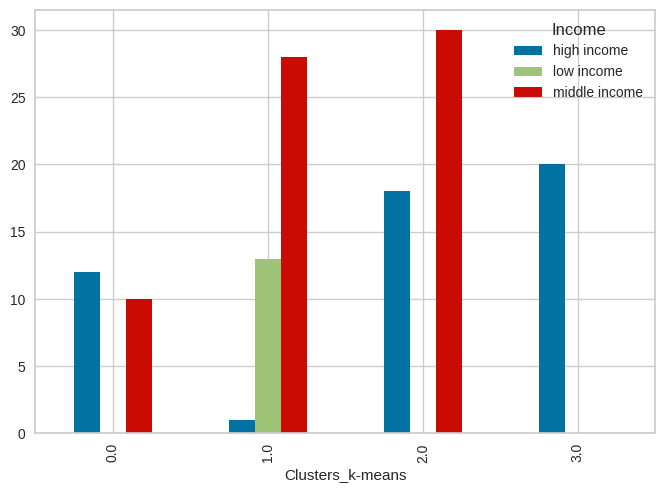

In [249]:
dnm.groupby(['Clusters_k-means'])['Income'].value_counts().unstack().plot(kind='bar')

Несколько изменился состав кластеров по уровню дохода. Теперь в кластер с самыми низкими показателями вошло больше государств со средним доходом (на 10 больше). Также вошла одна страна с высоким доходом (раньше не было ни одной). Все страны с низким доходом по-прежнему размещены в том же кластере. В результате применения метода k-средних главным образом произошло перераспределение количества стран со средним доходом. Их количество снизилось (на 8 стран) в кластере с наиболее высоким уровнем развития и использования технологий (кластер 0 в k-means и кластер 2 в иерархическом).

In [255]:
dnm.groupby(['Clusters_k-means'])['OECD members'].value_counts()

Clusters_k-means  OECD members
0.0               0               11
                  1               11
1.0               0               42
2.0               0               38
                  1               10
3.0               1               17
                  0                3
Name: count, dtype: int64

<Axes: xlabel='Clusters_k-means'>

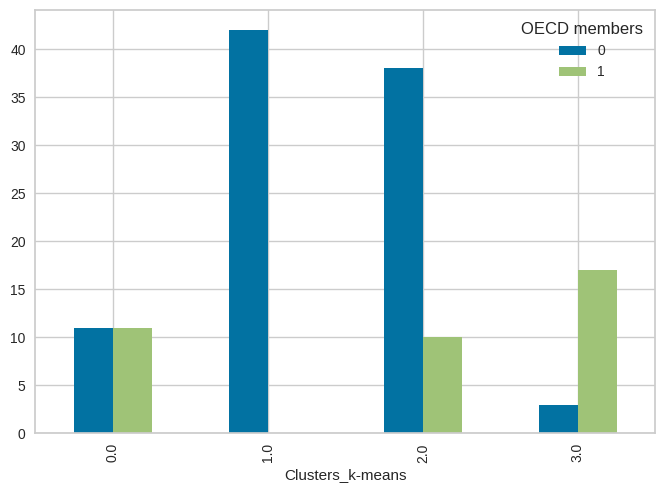

In [250]:
dnm.groupby(['Clusters_k-means'])['OECD members'].value_counts().unstack().plot(kind='bar')

Произошло некоторое перераспределение стран в кластерах в заивисимости от наличия членства в ОЭСР. В кластере с наиболее низкими показателями по-прежнему не представлены члены ОЭСР, но на 11 стран увеличилось количество не-членов. Состав кластера, где страны получали максимум по всем показателям (кластера 3 здесь и по иерархическому методу) остался почти неизменным. В 0 кластер (с развитыми технологиями) вошло больше стран не-членов ОЭСР (их число возросло на 3).

<Axes: xlabel='Clusters_k-means'>

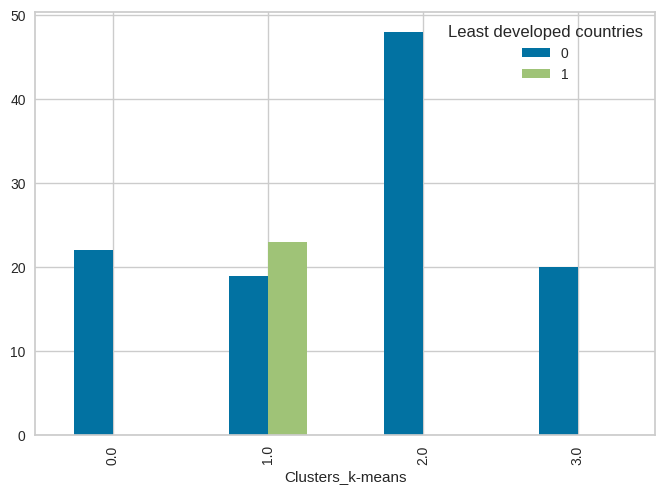

In [251]:
dnm.groupby(['Clusters_k-means'])['Least developed countries'].value_counts().unstack().plot(kind='bar')

В данном случае можно отметить, что по сравнению с распределением в иерархическом методе, все наименее развитые страны теперь были распределены в кластер с наиболее низкими показателями по всем переменным. В кластер более высокого уровня они распределены не были.

##Задание 5

5. Почему получилась именно такая кластерная структура? Полученные результаты соответствуют вашем изначальным предположениям или оказались неожиданными?

Факторы формирования кластеров:

- Технологическая база – ключевой дифференцирующий фактор. Страны с развитой научной инфраструктурой автоматически выделились в отдельный кластер из-за высокой плотности показателей по патентной активности и R&D-расходам.

- Институциональное развитие – страны с сильными госинститутами образовали отдельную группу, даже при средних показателях исследований.

- Ресурсная зависимость – экономики с преобладанием сырьевого сектора (страны Африки, Латинской Америки) сгруппировались вокруг низких значений ИКТ-инфраструктуры.

- Образование, развитый человеческий капитал.

Сюрпризы исследования:

Ожидали чёткого разделения на "богатые/бедные", но реальность сложнее: некоторые развивающиеся страны попали в кластер технологических "середняков" (4 кластер) благодаря точечным успехам в IT-экспорте.

Не предполагали, что экс-социалистические страны окажутся в одном кластере с латиноамериканскими государствами – видимо, сказывается общая проблема "полуфабрикатной" экономики (кластер 2)

Вся Северная Америка представлена только в кластере 4, где хотя и не самые высокие показатели по всем переменным (чуть-чуть ниже, чем в 3 кластере), но наиболее впечатляющие по степени развития науки и технологий.
Первоначальные гипотезы:

Подтвердилось:

Кластеризация по географическому принципу (африканские страны в одной группе). Предполагали, что наименее развитые страны попадут в кластер государств, которые находятся на начальном этапе своего развития (кластер 1). Также предполагали

Прямая связь между расходами на образование и инновационным потенциалом. Где высокие расходы на образование, существует направленность на развитие человеческого капитала, в тех странах большая склонность к развитию инноваций. И наоборот, с развитием инновационной активности открываются большие возможности для получения более высокого образовательного уровня.

Предполагали наличие кластера стран с более низким уровнем развития, сталкивающихся с трудностями в развитии цифрового сектора и инноваций, наличием не самодостаточного рынка.

На самом деле кластерная структура выглядит сложнее. Ее нельзя стандартно разделить на 3 кластера со низким, средним и высоким уровнями развития технологий, образования. Но нельзя разделить их просто на 3 кластера с условно низким, средним и высоким уровнями. Есть группа стран с низкими показателями, в которую преимущественно попали развивающиеся страны, представители наименее развитых стран, как и предполагалось. Но также выделились и более детальные группы, как 2 кластер, где пока относительно более низкие показатели, чем в 3 и 4, но за счет импорта и использования технологий, у них есть потенциал на развитие более независимого внутреннего рынка в перспективе.



Выводы:
Результаты не совсем совпали с ожиданиями. Главное открытие – невозможность однозначной кластеризации по уровню экономического развития. Видимо, в современном мире институциональные факторы и качество человеческого капитала играют бóльшую роль, чем абсолютные показатели ВВП.

### Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение других алгоритмов кластеризации и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе применения всех пройденных на занятиях алгоритмов кластеризации, сравнением результатов и выбором лучшей кластерной модели с объяснением своего выбора.
 - В этом задании пять пунктов. Первый весит 20%, второй - 5%, третий - 60%, четвертый - 10%, пятый - 5%.
 - Задание можно выполнять на русском или на английском языке, критерии оценивания при этом не меняются.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются.
 - Если задание выполняется вдвоем, то в Smart LMS работу загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 13:00 28 февраля.